<a href="https://colab.research.google.com/github/rojaspetit/analysis_everpeak/blob/main/Analysis_everpeak_PENDING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 7 - Análisis estadístico para detectar patrones y outliers

## Chapter 1 - Preparación de datos para análisis estadístico

### Lección 1 - Identificando variables relevantes para el análisis

#### Clasificar columnas por rol y tipo

In [2]:
# Importamos librerías y cargamos el dataset

import pandas as pd
df = pd.read_csv("everpeak_retail.csv")

In [ ]:
# Para comenzar, necesitamos entender qué información contiene el dataset y cómo está estructurado.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [ ]:
# CARDINALIDAD, otra pista para entender la estructura del dataset (valores únicos que contiene)
df.nunique().sort_values()

payment_method         4
product_category       8
state                  9
city                  10
customer_age          64
quantity             249
order_date           381
price               1677
customer_id         1829
order_value         3889
order_id            5008
dtype: int64

#### Identificar valores faltantes

In [ ]:
# Para obtener la proporción de faltantes según columna
df.isna().mean().sort_values(ascending=False)

customer_age        0.029952
city                0.019968
state               0.019968
order_date          0.001597
order_id            0.000000
customer_id         0.000000
product_category    0.000000
price               0.000000
quantity            0.000000
order_value         0.000000
payment_method      0.000000
dtype: float64

In [ ]:
df.isna().sum().sort_values(ascending=False)

customer_age        150
city                100
state               100
order_date            8
order_id              0
customer_id           0
product_category      0
price                 0
quantity              0
order_value           0
payment_method        0
dtype: int64

#### Identificar valores inválidos

In [ ]:
# Puede que no hayan datos faltantes, pero tal vez existan datos inválidos en algunas columnas.

In [ ]:
# product_category
# Revisión → Categorías invalidas

df["product_category"].value_counts()

Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
?               25
Name: product_category, dtype: int64

In [ ]:
# quantity
# Revisión → cantidades menores a cero (i.e. negativas)

df['quantity'].le(0).sum()

2971

In [ ]:
# customer_age
# Revisión→ edades improbables e.g. mayores a 100

df[['customer_age', 'quantity']].describe()

,customer_age,quantity
count,4858.000000,5008.000000
mean,43.728695,21.871406
std,77.130195,63.303488
min,-999.000000,0.000000
25%,34.000000,0.000000
50%,49.000000,0.000000
75%,65.000000,22.000000
max,80.000000,1266.000000


### Lección 3 - Manejando valores ausentes o inválidos

Ahora aprenderás una habilidad clave:

👉 No todos los valores faltantes significan lo mismo, y no se limpian igual.

👉 Los valores inválidos tampoco se limpian como los ausentes.

En esta lección aprenderás a:

* Clasificar las distintas causas de valores ausentes
* Elegir entre eliminar, imputar, o flags según el contexto

En esta lección veremos los dos casos más importantes del dataset:

* customer_age → la columna con más valores vacíos.
* quantity → la columna con los valores inválidos más serios.

#### Tipos de valores ausentes

##### 🔵 MCAR — Faltante completamente al azar (Missing Completely at Random)

Cuando la faltante es completamante al azar (completely at random), los datos faltan sin relación con otras variables ni con el valor en sí.

* La probabilidad de que falte una celda es la misma para todos los registros.
* El faltante se comporta como ruido puro.

💡 Efecto analítico: Si el porcentaje es bajo, eliminar esas filas no introduce un sesgo importante. Pierdes datos, pero de forma “neutral”.

##### 🟠 MAR — faltan siguiendo un patrón externo (Missing at Random)

Ocurre cuando la faltante es al azar (at random), pero la ausencia depende de otra variable que sí puedes observar.

* Por ejemplo: los campos de dirección faltan más cuando el pedido viene de cierto canal de venta o cierto método de pago, aunque dentro de ese canal todas las ciudades sean igual de probables.
* El problema está “explicado” por columnas que sí tienes.

💡 Efecto analítico: Puedes usar esas variables relacionadas para imputar con más criterio. El sesgo se puede manejar si lo documentas bien.

##### 🔴 MNAR — faltan porque el propio valor es especial

Cuando la falta no es al azar (not at random), depende de la propia variable faltante o de un proceso que no se ve en el dataset.

* Por ejemplo: los clientes con ingresos más altos son precisamente los que no completan el campo “ingreso”, porque no quieren revelarlo.
* Aquí el faltante es parte del fenómeno que quieres estudiar.

💡 Efecto analítico: Imputar a ciegas puede cambiar conclusiones estratégicas. Es mejor crear flags de missing, analizar explícitamente la “ausencia como señal”, y ser muy transparente en la documentación.

![image.png](attachment:image.png)

#### ¿Qué tipo de valor ausente es customer_age?

* ¿Las edades faltantes son simples “accidentes”? MCAR
* ¿Las edades faltantes pertenecen a un grupo especifico? MAR
* ¿Las edades faltan porque el propio valor es especial? MNAR

In [ ]:
# Revisar si los faltantes dependen de un grupo

# Posible dependencia a la Ciudad
df["customer_age"].isna().groupby(df["city"]).mean().sort_values(ascending=False)

city
New York         0.048290
Boston           0.037975
San Francisco    0.032051
Los Angeles      0.031311
Seattle          0.031189
Miami            0.030181
Phoenix          0.024440
Houston          0.023346
Chicago          0.020747
Denver           0.019523
Name: customer_age, dtype: float64

In [ ]:
# Posible dependencia a la Categoría de producto
df["customer_age"].isna().groupby(df["product_category"]).mean().sort_values(ascending=False)

product_category
Sports         0.049716
Electronics    0.031250
Home           0.029455
Grocery        0.027778
Beauty         0.027739
Fashion        0.025676
Toys           0.019471
?              0.000000
Name: customer_age, dtype: float64

In [ ]:
# Revisar si los faltantes muestran un comportamiento distinto / específico (especiales por si mismos)

# Crear nueva columna "flag"
df["edad_vacia"] = df["customer_age"].isna().astype(int)

# Mostrar columnas
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,edad_vacia
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0,0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0,0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0,0


In [ ]:
# Comprarar comportamiento de compra (order_value) entre clientes con/sin "customer_age"
df.groupby("edad_vacia")["order_value"].describe()

# Parece que customer_age es un MCAR.

,count,mean,std,min,25%,50%,75%,max
edad_vacia,,,,,,,,
0,4858.0,10108.75916,12406.435518,12.0,3158.25,10411.5,13163.0,303824.0
1,150.0,8866.96000,12102.064531,37.0,1993.75,5023.0,11405.5,78964.0


#### ¿Cómo imputar customer_age correctamente?

Si los valores faltantes en customer_age son MCAR (Missing Completely At Random) y representan solo ~3%, entonces la mejor práctica es elegir un método simple, estable y que no introduzca sesgos artificiales.

✅ Mejor opción: imputación con la mediana
* La mediana no se ve afectada por valores extremos.
* Mantiene la distribución general de la edad.
* Es ideal cuando la variable es numérica continua y los datos faltan al azar.
* Es el método más robusto, simple y apropiado cuando el faltante es bajo y MCAR

Otros métodos válidos, pero no necesariso en este caso

✔ Imputación por grupos (por ciudad, estado o categoría)
* Se usa cuando crees que la edad depende de otras variables.
* Pero como es MCAR, no es necesario complicarlo.

✔ Eliminar las filas faltantes
* Con solo 3% faltante, eliminar es posible… pero perderías datos inútilmente si puedes imputar bien.

In [ ]:
# Calcular mediana
median_age = df["customer_age"].median()
print(median_age)

49.0


In [ ]:
# Usar la mediana para imputar valores faltantes
df["customer_age"] = df["customer_age"].fillna(median_age)

In [ ]:
# Validar imputación
df["customer_age"].isna().sum()

0

#### ¿Cómo limpiar quantity <= 0 paso a paso?

In [ ]:
# 1) Valores inválidos en la columna de cantidad (quantity)
df["quantity"].le(0).sum()

2971

In [ ]:
# 2) Marcar como NaN los valores inválidos de quantity
import numpy as np

# Marcar como NaN los valores inválidos de quantity
df.loc[df["quantity"] <= 0, "quantity"] = np.nan

In [ ]:
# 3) Validar si la cantidad calcula coincide con la columna quantity

#Comprobamos si la cantidad calcula (order_value / price) ocincide con la columna quantity
df["calculated_quantity"] = (df["order_value"] / df["price"]).round()

# Verificamos las primeras filas donde la cantidad es cero o inválida
df[["order_value", "price", "quantity", "calculated_quantity"]].head()

,order_value,price,quantity,calculated_quantity
0,13385,269,50.0,50.0
1,660,66,NaN,10.0
2,5073,267,NaN,19.0
3,14290,114,125.0,125.0
4,11754,729,16.0,16.0


In [ ]:
# 4) Imputar quantity usando el cálculo de order_value / price
df["quantity"] = df["quantity"].fillna(df["order_value"] / df["price"])

In [ ]:
# 5) Revisar la imputación
df["quantity"].le(0).sum()

0

#### Conclusión

✔ customer_age
* No faltan según ciudad o producto → MAR/MNAR.
* Faltan de manera completamente al azar → MCAR
* Se debe imputar usando la mediana.
* Y es una buena práctica crear una bandera (nueva columna) edad_vacia

✔ quantity
* No tiene valores ausentes, tiene valores inválidos.
* No se clasifica en MCAR/MAR/MNAR.
* Se deben convertir a NaN y luego imputar o eliminar.

In [ ]:
# Patrón para calcular la proporción de valores faltantes por grupo.
# isna().groupby().mean()

In [ ]:
# Imputación para reemplazar faltantes por valores estimados (media, mediana, moda u otras reglas).
# fillna()

### Lección 5 - Funciones de Python para automatizar la limpieza de datos


In [ ]:
# Estructura:
# resultado = mi_funcion(entrada)

# Ejemplo:
def crear_saludo(nombre):
   print("Hola " + nombre)

crear_saludo("Ana")
crear_saludo("Pablo")
crear_saludo("Isabela")

Hola Ana
Hola Pablo
Hola Isabela


#### Estructura de una función en Python

In [ ]:
# def → le dice a Python “voy a definir una función”.

# Nombre de la función → típicamente en minúsculas, con guiones bajos: snake_case.

# Parámetros → las entradas entre paréntesis.
# No es obligatorio, pero comúnmente tenemos una o más entradas.

# return → lo que la función devuelve como resultado (no es obligatorio).



# Ejemplo básico:

def saludar(nombre):
     return "Hola " + nombre

# 1) def → comando
# 2) saludar → nombre de la función.
# 3) nombre → parámetro de entrada.
# 4) return "Hola " + nombre → salida de la función.

saludar("Edgar")

'Hola Edgar'

![image.png](attachment:image.png)

In [ ]:
# Ejemplo: Función SIN return

def saludar():
    print("Hola!")

# 👉 La función solo imprime "Hola!" porque tiene un print adentro.
# 👉 Pero como no tiene return, la variable donde guardas el resultado recibe None.
# 👉 Por eso, cuando imprimes esa variable, aparece None.

text = saludar() # la función imprime "Hola!"
print(text) # imprime None

Hola!
None


In [ ]:
# Ejemplo: Función CON return

def obtener_saludo():
        return "Hola!"

# 👉 No imprime nada.
# 👉 Pero puedes guardar y usar el valor

texto = obtener_saludo()
print(texto)   # Imprime: Hola!

Hola!


✔ En resumen

* Función sin return ---> Siempre devuelve None, aunque haga otras cosas.
* Función con return --->	Devuelve el valor que tú decides.

In [ ]:
# Return termina la ejecución de la función inmediatamente.
# Cualquier código después del return no se ejecuta:

def procesar_edad(edad):
    return f"Edad procesada: {edad}"
    print("Esto nunca se imprime")  # ⚠️ Código inalcanzable

resultado = procesar_edad(25)
print(resultado)

Edad procesada: 25


In [ ]:
# Sin return: La función ejecuta su código pero devuelve None automáticamente.

In [ ]:
def procesar_edad(edad):
    print("Edad procesada: ", edad)
    print("Esto nunca se imprime")  # ⚠️ Código inalcanzable (aquí llega porque no hay RETURN)

resultado = procesar_edad(25)
print(resultado)

Edad procesada:  25
Esto nunca se imprime
None


In [ ]:
# Esto es útil cuando solo quieres que la función haga algo
# (como imprimir o modificar datos) sin necesitar un valor de regreso.

In [ ]:
def mostrar_mensaje(nombre, ciudad):
    print(f"{nombre} vive en {ciudad}")  # Solo imprime, no retorna nada

resultado = mostrar_mensaje("Carlos", "Madrid")
print("El valor retornado es:", resultado)

Carlos vive en Madrid
El valor retornado es: None


In [ ]:
def mostrar_mensaje(nombre, ciudad):
    print(f"{nombre} vive en {ciudad}")  # Solo imprime, no retorna nada

mostrar_mensaje("Carlos", "Madrid")

Carlos vive en Madrid


#### Ejecutar código directo vs. envolverlo en una función


In [ ]:
# Código manual

mensaje = "Hola Ana"
print(mensaje)

Hola Ana


In [ ]:
# Lógica dentro de una función

def crear_saludo(nombre):
    return "Hola " + nombre

print(crear_saludo("Ana"))
print(crear_saludo("Luis"))
print(crear_saludo("Carla"))

Hola Ana
Hola Luis
Hola Carla


![image.png](attachment:image.png)

#### Ejemplos pequeños para generar confianza


##### Funciones con un parámetro. Función elevar_al_cuadrado(x)


In [ ]:
# Crear función

def elevar_al_cuadrado(x):
    print ("El cuadrado de", x, "es", x*x)

# Usar función

elevar_al_cuadrado(4)
elevar_al_cuadrado(10)
print() #salto de línea

# Intentar guardar e impimir el resultado
resultado = elevar_al_cuadrado(-3)
print(resultado)

El cuadrado de 4 es 16
El cuadrado de 10 es 100

El cuadrado de -3 es 9
None


##### Funciones con un parámetro en LIMPIEZA. Función estandarizar_nombre(nombre)

In [ ]:
# Crear función

def estandarizar_nombre(nombre):
    return nombre.strip().lower()

# Usar función

print(estandarizar_nombre("    ANA    "))
print(estandarizar_nombre(" LuIS    "))
print(estandarizar_nombre("    CArlA"))

ana
luis
carla


##### Funciones con múltiples parámetro en LIMPIEZA. Función formatear_nombre(nombre, apellido)


In [ ]:
# Crear función

def formatear_nombre(nombre, apellido):
    nombre_formateado = nombre.strip().title()
    apellido_formateado = apellido.strip().title()
    return f"El apellido de {nombre_formateado} es {apellido_formateado}"

# Usar función

print(formatear_nombre("    ana   ","GRACÍA"))
print(formatear_nombre(" CARLOS", "lópez     "))
print(formatear_nombre("    María   ","Rodríguez    "))
print() #salto de línea
print(formatear_nombre("    Rodríguez   ","María")) # Caso invertido, se debe mantener consistencia

El apellido de Ana es Gracía
El apellido de Carlos es López
El apellido de María es Rodríguez

El apellido de Rodríguez es María


##### Funciones numéricas con múltiples parámetros

In [ ]:
# Crear función

def calcular_descuento(precio, porcentaje_descuento):
    tasa_descuento = porcentaje_descuento / 100 # convertir porcentaje a decimal
    descuento = precio * tasa_descuento # calcular descuento
    return precio - descuento # restar el descuento al precio

# Usar función, primero precio, después descuento

print(calcular_descuento(100,10))
print(calcular_descuento(250,20))
print(calcular_descuento(50,15))

90.0
200.0
42.5


### Lección 7 - Bucles (for & while) e iterables en una colección


Un loop o bucle es una estructura que permite recorrer una colección de elementos y ejecutar la misma acción en cada uno.

📖 Considera lo siguiente:   
* Las funciones definen “qué hacer”
* Los bucles definen “a cuántos elementos se aplican”

#### Bucle for: el más usado en limpieza

In [ ]:
# Se usa para recorrer colecciones: listas, strings, diccionarios, rangos, etc.

# for elemento in coleccion:
    # hacer algo con elemento

In [ ]:
columnas_a_revisar = ["product_category", "customer_segment", "city"]

for col in columnas_a_revisar:
    print("Revisando:", col)

Revisando: product_category
Revisando: customer_segment
Revisando: city


In [ ]:
# Ventajas del buble loop

#Importar Pandas y cargar datos
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')

In [ ]:
# Caso manual

print("product_category nulos:", df["product_category"].isna().sum())
print("quantity nulos:", df["quantity"].isna().sum())
print("city nulos:", df["city"].isna().sum())

product_category nulos: 0
quantity nulos: 0
city nulos: 100


In [ ]:
# Caso con buble for

columnas = ["product_category","quantity","city"] #solo debo añadir aquí para aumentar análisis

for col in columnas:
    print(col, "nulos:", df[col].isna().sum())

product_category nulos: 0
quantity nulos: 0
city nulos: 100


![image.png](attachment:image.png)

In [ ]:
# Ejemplo:

productos = ["ropa", "calzado", "accesorios"]

for p in productos:
    print("Procesando:", p)

Procesando: ropa
Procesando: calzado
Procesando: accesorios


In [ ]:
# Ejemplo

# lista de frutas
frutas = ["manzana","pera","piña","uva"]

# crea el bucle
for fruta in frutas:
    print("Procesando:", fruta)

Procesando: manzana
Procesando: pera
Procesando: piña
Procesando: uva


In [ ]:
# Ejercicio: strings (colecciones de caracteres)
# Un string también es una colección: "DATA" son cuatro caracteres.
# Objetivo: Recorrer caracteres de una palabra.

texto = "DATA"

for letra in texto:
    print(letra)

D
A
T
A


In [ ]:
# 💡 Un bucle toma cada elemento de la colección, uno por uno, y aplica la MISMA acción,
# sin que tengas que escribir una línea nueva por elemento.

#### Bucle while: repetir mientras una condición sea verdadera

In [ ]:
# El bucle while repite un bloque de código mientras una condición sea verdadera. Su Sintaxis es:

# while condicion:
    # código que se repite

Se usa cuando:

* No sabes cuántas repeticiones habrá,
* Repites hasta que se cumpla una condición,
* Necesitas un contador manual o un proceso “hasta que quede limpio”.

In [ ]:
# Ejemplo
# Mientras el contador sea mayor a cero (contador > 0), print su valor y después le restamos 1.

contador = 3

while contador > 0:
    print("Contador:", contador)
    contador = contador - 1

print("\nBucle terminado")

Contador: 3
Contador: 2
Contador: 1

Bucle terminado


⚠️Si olvidas actualizar contador dentro del bucle, este nunca termina → por eso los while requieren más cuidado.

💡 En limpieza y análisis de datos, usamos más el for porque es más seguro y predecible. Dejamos while para casos específicos, siempre revisando que el bucle termine.

In [ ]:
# Ejemplo - Validar hasta que un valor cumpla una regla
# Objetivo: Recopilar registros de ventas hasta llegar a 1,000 productos.

ventas = 993

#completa el código dentro del while
while ventas <= 1000:
    print("Ventas registradas:", ventas)
    ventas = ventas + 1

# imprimir mensaje final
print("\n¡Meta de ventas alcanzada!")

Ventas registradas: 993
Ventas registradas: 994
Ventas registradas: 995
Ventas registradas: 996
Ventas registradas: 997
Ventas registradas: 998
Ventas registradas: 999
Ventas registradas: 1000

¡Meta de ventas alcanzada!


#### Cómo usan bucles los analistas de datos


##### Caso 1: Aplicar reglas de formato a una lista de textos (normalizar cadenas)

Los analistas limpian texto constantemente: nombres, ciudades, categorías, métodos de pago, etc. Lo ideal es encapsular el proceso dentro de una función y luego aplicar esa función dentro de un bucle.

In [ ]:
# Creamos la función

def limpiar_cadenas(lista_de_texto):
    for texto in lista_de_texto:
        print(texto.strip().title())

# Diferentes entradas a limpiar

nombres_crudos_1 = ["  ANA  ", "LuIs ", " CARLA"]
nombres_crudos_2 = ["  ANA"," CArlos ", "Daniel ", "TanIA"]

# Aplicamos la función con diferentes entradas

limpiar_cadenas(nombres_crudos_1)
print()
limpiar_cadenas(nombres_crudos_2)

Ana
Luis
Carla

Ana
Carlos
Daniel
Tania


##### Caso 2: Buscar sentinels en múltiples columnas (EverPeak)


Este es un problema clásico: EverPeak usa -999 como valor inválido en varias columnas numéricas. En vez de escribir una celda por cada columna, un analista automatiza la inspección así:



In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

columnas = ["customer_age", "quantity", "order_value"]
sentinel = -999

for col in columnas:
    print(col,"→", (df[col] == -999).sum())

customer_age → 25
quantity → 0
order_value → 0


In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

columnas = ["customer_age", "quantity", "order_value"]
sentinel = -999

for col in columnas:
    print(col,"→", df[col].isin([-999]).sum())

customer_age → 25
quantity → 0
order_value → 0


##### Caso 3: Iterar sobre columnas para aplicar funciones personalizadas


Un analista rara vez limpia solo una columna. Normalmente limpia bloques completos:

In [ ]:
columnas_texto = ["city", "state", "product_category"]

for col in columnas_texto:
    df[col] = df[col].str.strip().str.lower()

### Lección 9 - Escribiendo tus primeras mini-funciones de limpieza de datos


En la lecciones anterior aprendiste a usar bucles for para repetir una misma instrucción varias veces.

También aprendiste a crear funciones que aplican una regla clara a un solo valor.


¿ Cómo colocar un loop dentro de una función para automatizar una regla sobre varias columnas a la vez?

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

#### El problema real: repetición innecesaria

In [ ]:
# Si quisiéramos convertir varias columnas a tipo numérico sin loops, tendríamos que escribir:

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["order_value"] = pd.to_numeric(df["order_value"], errors="coerce")

* Esto no escala.
* Añadir una columna nueva implica escribir otra línea.
* Cambiar la regla implica cambiarla en muchos lugares.

Como analistas, queremos evitar eso.

#### Intento intermedio: crear una función por cada columna

In [ ]:
# ✔️ Crear una función para price
def convertir_price(df):
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    return df

# ✔️ Crear una función para quantity
def convertir_quantity(df):
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    return df

# ✔️ Crear una función para order_value
def convertir_order_value(df):
    df["order_value"] = pd.to_numeric(df["order_value"], errors="coerce")
    return df

# Y luego las llamamos:
df = convertir_quantity(df)
df = convertir_order_value(df)
df = convertir_price(df)

¿Qué problema aparece aquí?

❌ Seguimos teniendo código repetido dentro de cada función

Las funciones tienen la misma lógica: df[col] = pd.to_numeric(df[col], errors="coerce")

❌ Seguimos teniendo que escribir una función por columna

Si EverPeak agrega "discount" o "shipping_fee", tenemos que escribir otra función más.

❌ Si la regla cambia, debemos actualizar TODAS las funciones

Si mañana usamos otro método de conversión, debemos modificar 3, 4 o 10 funciones.

💡 Esto nos lleva a la solución correcta: una sola función + un loop.
En lugar de escribir una función por columna, podemos escribir una única función que recibe una lista de columnas y usa un loop interno para aplicar la misma regla a cada una. Esto elimina completamente la repetición de código y hace la limpieza escalable.



#### Cómo un loop dentro de una función evita repetir código

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
df

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0
...,...,...,...,...,...,...,...,...,...,...,...
5003,5004,NaN,1154,Fashion,368,0,6256,debit_card,Miami,FL,22.0
5004,5005,NaN,1408,Electronics,687,15,10025,credit_card,Houston,TX,80.0
5005,5006,NaN,2935,Toys,797,0,5579,credit_card,Miami,FL,35.0
5006,5007,NaN,2452,Toys,228,0,4332,credit_card,Miami,FL,42.0


In [ ]:
df.info()
# hay que transformar price, quantity y order_value explícitamente to numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [ ]:
# Creación de función + loop
# Función para convertir
# Función para aplicar la regla en todas las listas de columnas numéricas

def convertir_columnas_numericas (df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

In [ ]:
# Ejecutar la función utilizando una lista

columnas_numericas = ["price", "quantity", "order_value"]

df = convertir_columnas_numericas(df, columnas_numericas)
df.info()

# Todas quedaron en formato numérico

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [ ]:
# Escalar con un cambio simple

columnas_numericas.append("customer_age")
df = convertir_columnas_numericas(df, columnas_numericas)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


### Lección 11 - Construyendo un pipeline completo para limpieza de datos

En las últimas lecciones aprendiste tres pilares esenciales del trabajo de un analista:

* Cómo diagnosticar la calidad de los datos.
* Cómo usar funciones para encapsular reglas.
* Cómo usar bucles for para repetir una misma función sobre varias columnas.

Ahora vamos a dar un paso grande hacia el mundo real:  Construir un pipeline completo de limpieza

1) Recibir un DataFrame con los datos crudos de EverPeak (everpeak_retail.csv).
2) Aplicar varias funciones de limpieza en el orden correcto.
3) Devolver un DataFrame limpio que se exporta como everpeak_clean.csv.

Los pipelines son fundamentales para estandarizar limpiezas y reducir errores manuales, permitiendo que cualquier analista ejecute el mismo proceso con un solo comando.

Objetivo:

* Combinar funciones pequeñas en un solo pipeline clean_data(df).
* Ordenar los pasos de limpieza: nombres → tipos → valores faltantes/invalidos.
* Escribir una función main() que carga → limpia → exporta el archivo final.

#### ¿Qué es un “pipeline” de limpieza?


Un pipeline de limpieza es un programa que limpia datos sucios para su análisis. Su objetivo es ser reutilizable,  sin tener que escribir nuevamente todo el código cada vez que necesites procesar datos nuevos.

1) Entra el dataset crudo.
2) Pasa por una serie de etapas ordenadas:
 * Estandarizar texto
 * Convertir tipos
 * Tratar valores inválidos y faltantes.
3) Sale un dataset limpio, listo para el análisis.

In [ ]:
# Suele verse así:
# Función para limpiar datos

# def limpiar_datos(df):
  #  df = paso_limpia_texto(df) #funcion para limpiar texto
  #  df = paso_corrige_edad(df) #funcion para corregir edad
  #  df = paso_convierte_tipos(df) #funcion para convertir tipo de datos
  #  return df

# Cada paso, recibe un DF, aplica una función, regresa un DF actualizado

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
df

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0
...,...,...,...,...,...,...,...,...,...,...,...
5003,5004,NaN,1154,Fashion,368,0,6256,debit_card,Miami,FL,22.0
5004,5005,NaN,1408,Electronics,687,15,10025,credit_card,Houston,TX,80.0
5005,5006,NaN,2935,Toys,797,0,5579,credit_card,Miami,FL,35.0
5006,5007,NaN,2452,Toys,228,0,4332,credit_card,Miami,FL,42.0


#### Función 1: Estandarizar sentinels y valores inválidos

In [ ]:
# Recordemos el diagnóstico de la Lección 3 Manejando valores ausentes o inválidos:

# 🔎 Diagnóstico

# customer_age usa -999 para indicar edades inválidas.
# product_category usa "?" para indicar categorías desconocidas (no hay NaNs).

# Para solucionar esto:
# En customer_age, reemplazamos los -999 por NaNs para habilitar funciones de valores ausentes.
#df["customer_age"] = df["customer_age"].replace(-999, pd.NA)
# En product_category , dado que no teníamos NaNs, pasamos directamente a imputar con "unknown".
#df["product_category"] = df["product_category"].replace("?", "unknown")

In [ ]:
# crear función para estandarizar sentinels

def reemplazar_sentinels_global(df, numeric_cols, text_cols):
    numeric_sentinels = [-999,999]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace(numeric_sentinels, pd.NA)

    text_sentinels = ["?"]
    for col in text_cols:
        df[col] = df[col].replace(text_sentinels, "unknown")

    return df

In [ ]:
# establecer columnas a procesar

columnas_numericas = ["customer_age"] # columnas numéricas a procesar
columnas_texto = ["product_category"] # columnas de texto a procesar

In [ ]:
# aplicar función

reemplazar_sentinels_global(df, columnas_numericas, columnas_texto)

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0
...,...,...,...,...,...,...,...,...,...,...,...
5003,5004,NaN,1154,Fashion,368,0,6256,debit_card,Miami,FL,22.0
5004,5005,NaN,1408,Electronics,687,15,10025,credit_card,Houston,TX,80.0
5005,5006,NaN,2935,Toys,797,0,5579,credit_card,Miami,FL,35.0
5006,5007,NaN,2452,Toys,228,0,4332,credit_card,Miami,FL,42.0


In [ ]:
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          5008 non-null   int64 
 1   order_date        5000 non-null   object
 2   customer_id       5008 non-null   int64 
 3   product_category  5008 non-null   object
 4   price             5008 non-null   int64 
 5   quantity          5008 non-null   int64 
 6   order_value       5008 non-null   int64 
 7   payment_method    5008 non-null   object
 8   city              4908 non-null   object
 9   state             4908 non-null   object
 10  customer_age      4833 non-null   object
dtypes: int64(5), object(6)
memory usage: 430.5+ KB
   order_id  order_date  customer_id product_category  price  quantity  \
0         1  2024-02-02         2616           Sports    269        50   
1         2  2024-10-10         1736          Grocery     66         0   
2         3  2024-08-

#### Función 2: Crear flags antes de imputar

In [ ]:
# Recordemos el diagnóstico de la Lección 3 Manejando valores ausentes o inválidos:

# 🔎 Diagnóstico
# customer_age es completamente al azar (MCAR)
# city y state son completamente al azar (MCAR)

# Para solucionar esto, usamos columnas nuevas (..._flags)  para conservar la
# información original sobre qué valores estaban ausentes.

#df["age_missing_flag"] = df["customer_age"].isna().astype(int)
#df["city_missing_flag"] = df["city"].isna().astype(int)
#df["state_missing_flag"] = df["state"].isna().astype(int)

Convertimos el código a una función que:

* Recibe el DataFrame y las columnas que queremos marcar
* Recorre cada columna con un bucle y crea su columna flag correspondiente
* Devuelve el DF con las nuevas columnas añadidas

In [ ]:
# crear función para crear columnas flags

def crear_flags(df, flags_cols):                     # Estructura (recibo df y una lista)
    for col in flags_cols:                           # Para los elementos de la lista...
        nombre_flag = col + "_missing_flag"          # Defino un nombre a la nueva columna
        df[nombre_flag] = df[col].isna().astype(int) # Defino como se llena la nueva columna (nulos)
    return df                                        # Pido que se me regrese el DF limpio

In [ ]:
# establecer columnas a procesar

columnas_flags = ["customer_age", "city", "state"]

In [ ]:
# aplicar función y mostrar resultados

df = crear_flags(df, columnas_flags)
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   order_id                   5008 non-null   int64 
 1   order_date                 5000 non-null   object
 2   customer_id                5008 non-null   int64 
 3   product_category           5008 non-null   object
 4   price                      5008 non-null   int64 
 5   quantity                   5008 non-null   int64 
 6   order_value                5008 non-null   int64 
 7   payment_method             5008 non-null   object
 8   city                       4908 non-null   object
 9   state                      4908 non-null   object
 10  customer_age               4833 non-null   object
 11  customer_age_missing_flag  5008 non-null   int64 
 12  city_missing_flag          5008 non-null   int64 
 13  state_missing_flag         5008 non-null   int64 
dtypes: int64

#### Función 3: Imputar valores ausentes según diagnóstico

##### 🔎 L3 Manejando valores ausentes o inválidos. Diagnóstico #1  -  customer_age

In [ ]:
# customer_age tiene missing moderado (150 casos ≈ 3%).
# Es un caso MCAR no depende de otras variables ni es especial por si misma.

# Para solucionar esto, rellenamos los valores ausentes con la mediana de esa columna.
#age_median = df["customer_age"].median() # obtener mediana de customer_age
#df["customer_age"] = df["customer_age"].fillna(age_median) # rellenar ausentes

In [ ]:
# Como PASO INTERMEDIO antes de crear la función para imputar,
# usamos un bucle para que este código pueda recibir diferentes columnas.

# El bucle recorre la lista de columnas (median_fill) que queremos rellenar con la mediana.
# En cada columna, convertimos a numeric, calculamos mediana y reemplazamos los NaN con ella.

median_fill_cols =["customer_age"]

for col in median_fill_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    med = df[col].median()
    df[col] = df[col].fillna(med)

##### 🔎 L3 Manejando valores ausentes o inválidos. Diagnóstico #2 - city, state

In [ ]:
# city y state tienen missing muy bajo (≈ 2%).
# Ambas columnas tienen missing similar.
# Hay MCAR uniforme en todos los métodos de pago.
# No hay razón de negocio para eliminarlo.

# Para solucionar esto, rellenamos los valores ausentes con el texto "unknown".
#df["city"] = df["city"].fillna("unknown")
#df["state"] = df["state"].fillna("unknown")

In [ ]:
# Como PASO INTERMEDIO antes de crear la función para imputar,
# nuevamente, agregamos un bucle que recorre las columnas a rellenar, para automatizar este código:

fill_unknown_cols = ["city", "state"]   # lista de columnas a rellenar con unknown

for col in fill_unknown_cols:
    df[col] = df[col].fillna("unknown")

##### 🔎 L3 Manejando valores ausentes o inválidos. Diagnóstico #3 - order_date

In [ ]:
# order_date tiene 8 missing ≈ 0.24%
# MCAR: los faltantes no se ven relacionados con categoría
# No se pueden imputar sin inventar registros falsos

# Esto se soluciona eliminando los valores ausentes en esa columna.
# df = df.dropna(subset=["order_date"])

In [ ]:
# Transformamos el código agregándole un bucle para que pueda procesar más columnas de fecha.
# En cada iteración:
# 1) primero convertimos la columna a tipo fecha y cualquier registro invalido se convierte a NaN.
# 2) eliminamos los registros que tengan valores ausentes en esa misma columna.
# 3) reiniciamos el índice del DF. Aquí drop=True descarta el índice anterior y genera uno nuevo.

date_drop_cols = ["order_date"]

for col in date_drop_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
    df = df.dropna(subset=[col]).reset_index(drop=True)

##### Creación de función 3

In [ ]:
# crear función 3: imputar según diagnóstico

# 1) Recibe como entrada un DF y las listas de columnas numéricas, categóricas y de fechas a imputar
# 2) Rellena los valores ausentes de esas columnas numéricas con la mediana
# 3) Rellena los valores ausentes de esas columnas categóricas con "unknown"
# 4) Elimina los valores ausentes de esas columnas de tipo fecha

def imputar_segun_diagnostico (df, median_fill_cols, fill_unknown_cols, date_drop_cols):

    # rellenar con la mediana en columnas numéricas
    for col in median_fill_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        med = df[col].median()
        df[col] = df[col].fillna(med)

    # rellenar con texto "unknown" en columnas categóricas
    for col in fill_unknown_cols:
        df[col] = df[col].fillna("unknown")

    # eliminar registros con valores ausentes en columnas tipo fecha
    for col in date_drop_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df = df.dropna(subset=[col]).reset_index(drop=True)

    return df

In [ ]:
# establecer columnas a procesar
cols_imputar_mediana = ["customer_age"]
cols_imputar_unknown = ["city", "state"]
cols_imputar_fecha = ["order_date"]

In [ ]:
# aplicar función y mostrar resultados
df = imputar_segun_diagnostico(df, cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_id                   5000 non-null   int64         
 1   order_date                 5000 non-null   datetime64[ns]
 2   customer_id                5000 non-null   int64         
 3   product_category           5000 non-null   object        
 4   price                      5000 non-null   int64         
 5   quantity                   5000 non-null   int64         
 6   order_value                5000 non-null   int64         
 7   payment_method             5000 non-null   object        
 8   city                       5000 non-null   object        
 9   state                      5000 non-null   object        
 10  customer_age               5000 non-null   float64       
 11  customer_age_missing_flag  5000 non-null   int64         
 12  city_m

#### Combinando funciones en un solo pipeline

In [ ]:
# Importación del data set

import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

##### Mini-funciones

In [ ]:
# Función para estandarizar sentinels
def reemplazar_sentinels_global(df, numeric_cols, text_cols):
    numeric_sentinels = [-999,999]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace(numeric_sentinels, pd.NA)

    text_sentinels = ["?"]
    for col in text_cols:
        df[col] = df[col].replace(text_sentinels, "unknown")

    return df

# Función para crear columnas flags
def crear_flags(df, flags_cols):                     # Estructura (recibo df y una lista)
    for col in flags_cols:                           # Para los elementos de la lista...
        nombre_flag = col + "_missing_flag"          # Defino un nombre a la nueva columna
        df[nombre_flag] = df[col].isna().astype(int) # Defino como se llena la nueva columna (nulos)
    return df                                        # Pido que se me regrese el DF limpio

# Función para imputar valores de mediana, desconocido y eliminar ausentes
def imputar_segun_diagnostico (df, median_fill_cols, fill_unknown_cols, date_drop_cols):

    # rellenar con la mediana en columnas numéricas
    for col in median_fill_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        med = df[col].median()
        df[col] = df[col].fillna(med)

    # rellenar con texto "unknown" en columnas categóricas
    for col in fill_unknown_cols:
        df[col] = df[col].fillna("unknown")

    # eliminar registros con valores ausentes en columnas tipo fecha
    for col in date_drop_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df = df.dropna(subset=[col]).reset_index(drop=True)

    return df

##### Construyendo clean_data()

In [ ]:
def clean_data(df, numeric_cols, text_cols, flags_cols,
               median_fill_cols, fill_unknown_cols, date_drop_cols):

    # Sentinels: reemplazar marcadores inválidos por NaN
    df = reemplazar_sentinels_global(df, numeric_cols, text_cols)

    # Flags: crear banderas antes de imputar
    df = crear_flags(df, flags_cols)

    # Imputaciones / Drops finales
    df = imputar_segun_diagnostico(df, median_fill_cols, fill_unknown_cols, date_drop_cols)

    return df

##### Aplicar pipeline al dataset de EverPeak


In [ ]:
# main_pipeline.py
# DataFrame a procesar: Everpeak
df = pd.read_csv("/datasets/everpeak_retail.csv")

# Listas de columnas - incluir columnas según las necesidades del dataset
# columnas a procesar del dataset EverPeak

## columnas función 1: reemplazar_sentinels
columnas_numericas = ["customer_age"]
columnas_texto = ["product_category"]

## columnas función 2: crear_flags
columnas_flags = ["customer_age", "city", "state"]

## columnas función 3: imputar_segun_diagnostico
cols_imputar_mediana = ["customer_age"]
cols_imputar_unknown = ["city", "state"]
cols_imputar_fecha = ["order_date"]

# aplicar función y guardar resultado en df_clean
df_clean = clean_data(df, columnas_numericas, columnas_texto, columnas_flags,
    cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)

In [ ]:
# guardar df_clean en un CSV nuevo
df_clean.to_csv("everpeak_clean.csv", index=False)

Con esta lección dejaste de escribir pasos aislados y construiste un flujo de limpieza real y reutilizable.

## Chapter 2 - Describiendo distribuciones de datos

### Lección 1 - Medidas Estadísticas en Columnas NUMÉRICAS

Después de limpiar el dataset, el equipo quiere entender cómo se distribuyen los datos para tomar decisiones informadas.

En esta parte del caso de negocios, surgen las preguntas:
* ¿Los clientes realmente gastan “en promedio” lo que creemos?
* ¿Ese promedio representa al cliente típico o a unos pocos casos raros?

👉 No todas las métricas resumen bien la realidad.

👉 El error más común es confiar solo en el promedio. La media suena útil, pero a veces miente, especialmente cuando hay valores extremos o distribuciones desbalanceadas.

ℹ️ Nota: Trabajaremos con everpeak_clean, que es la versión limpia obtenida tras los pasos de la lección anterior.

#### Por qué el promedio puede mentirte


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/datasets/everpeak_clean.csv")

In [ ]:
mean_price = df["price"].mean()
median_price = df["price"].median()

print("Promedio:", mean_price)
print("Mediana:", median_price)

Promedio: 756.3874
Mediana: 457.0


In [ ]:
# La media es muy sensible a valores extremos.
# En este caso, hay producto premium que aumenta el promedio.

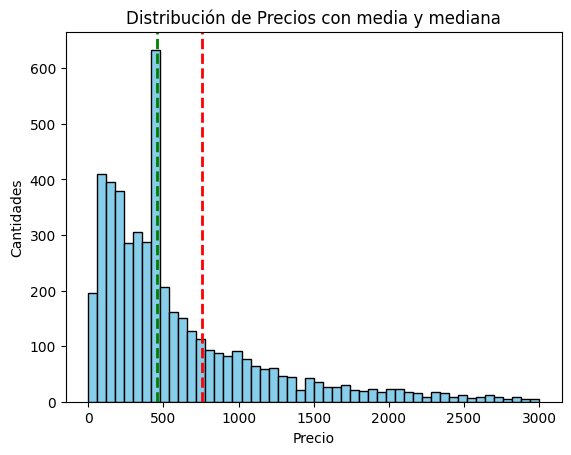

In [ ]:
# Creamos un gráfico para visualizar mejor media y mediana:

# Graficar histograma
plt.hist(df["price"], bins=50, range=(0,3000), color="skyblue", edgecolor="black")

# Agregar líneas de media y mediana solo con el nombre
plt.axvline(mean_price, color="red", linestyle="dashed", linewidth=2, label="Media")
plt.axvline(median_price, color="green", linestyle="dashed", linewidth=2, label="Mediana")

# Títulos y etiquetas
plt.title("Distribución de Precios con media y mediana")
#plt.legend(loc="upper_left")
plt.xlabel("Precio")
plt.ylabel("Cantidades")
plt.show()

In [ ]:
# Si solo usamos Promedio, estaríamos sobreestimando el valor de un producto aleatorio.

#### Distribuciones distintas con el mismo promedio

A veces dos columnas pueden tener exactamente el mismo promedio, pero comportarse de formas completamente diferentes.

Necesitamos entender:

* La forma de la distribución
* La mediana
* La dispersión
* revisar medidas como mínimo y máximo, que muestran el rango completo.

![image.png](attachment:image.png)

In [ ]:
# EJEMPLO - Comparando grupos con el mismo promedio.
# ¿Qué metodología de enseñanza rinde mejor? Clase 1, 2 y 3

import pandas as pd
import matplotlib.pyplot as plt

df_math = pd.read_csv("/datasets/math_class.csv")
df_math.head()

,student_id,class_name,score
0,1,Clase 1,51.0
1,2,Clase 1,50.0
2,3,Clase 1,51.0
3,4,Clase 1,53.0
4,5,Clase 1,50.0


In [ ]:
df_class1 = df_math[df_math["class_name"] == "Clase 1"]
df_class2 = df_math[df_math["class_name"] == "Clase 2"]
df_class3 = df_math[df_math["class_name"] == "Clase 3"]

print("Media Clase 1:", df_class1["score"].mean())
print("Media Clase 2:", df_class2["score"].mean())
print("Media Clase 3:", df_class3["score"].mean())

# Todavía no podemos concluir que, con estos resultados, todas las clases se comporten igual

Media Clase 1: 49.84
Media Clase 2: 50.13
Media Clase 3: 50.87


In [ ]:
# Calculamos más medidas (std, min, max)

df_lista = [df_class1, df_class2, df_class3]

for df in df_lista:
    print("Media:", df["score"].mean())
    print("Mínimo:", df["score"].min())
    print("Máximo:", df["score"].max())
    print("Desviación estándar:", df["score"].std())
    print("     ")

Media: 49.84
Mínimo: 45.0
Máximo: 54.0
Desviación estándar: 1.851671371676645
     
Media: 50.13
Mínimo: 37.0
Máximo: 69.0
Desviación estándar: 6.650973954651645
     
Media: 50.87
Mínimo: 1.0
Máximo: 100.0
Desviación estándar: 16.016188149128457
     


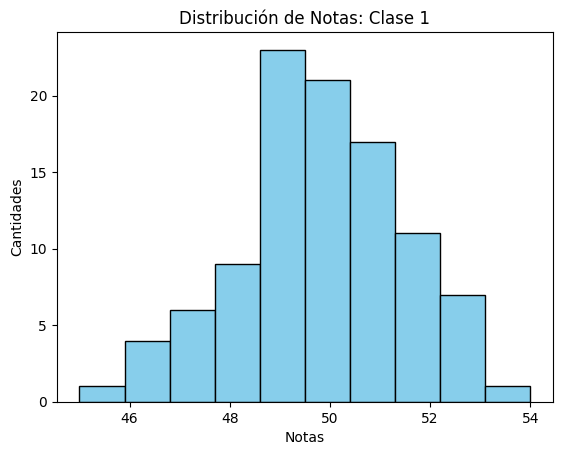

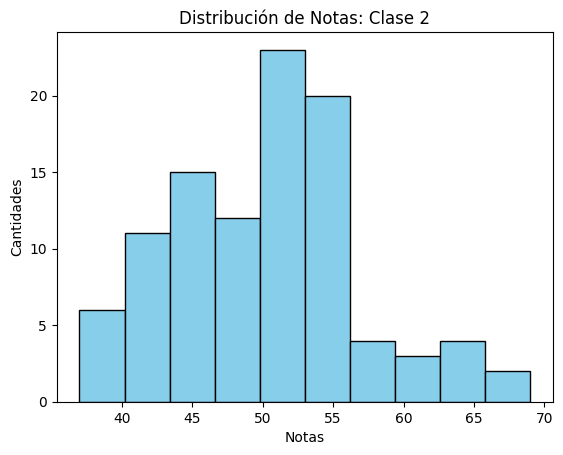

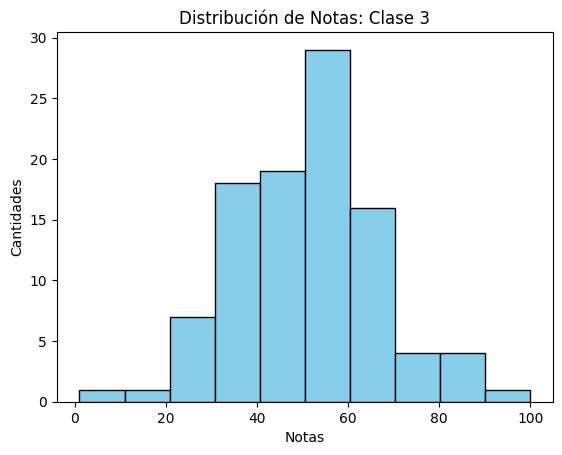

In [ ]:
# Creamos histogramas

df_lista = [df_class1, df_class2, df_class3]
class_num = 1

for df in df_lista:
    plt.hist(df["score"], bins=10, color="skyblue", edgecolor="black")

    # Títulos y ejes
    plt.title(f"Distribución de Notas: Clase {class_num}")
    plt.xlabel("Notas")
    plt.ylabel("Cantidades")
    plt.show()

    class_num += 1

In [ ]:
# La metodología de la clase 1 es la más efectiva, menos variabilidad, rendimiento más estable (?)
# Un alumno que estudie con la metodología 1, tiene más chance de obtener una calificación aprobatoria

#### Aplicación en el dataset de EverPeak

Volvamos al dataset EverPeak para aplicar lo aprendido y responder preguntas clave del negocio:

* ¿Cuánto paga típicamente un cliente?
* ¿Qué edad tiene un cliente promedio?
* ¿Qué tan variable es el precio de los productos?
* ¿La cantidad comprada suele ser estable o dispersa?

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# Aplicamos describe a las columnas numéricas
print(df[["order_value", "customer_age", "price", "quantity"]].describe())

         order_value  customer_age         price     quantity
count    5000.000000   5000.000000   5000.000000  5000.000000
mean    10075.523800     49.120800    756.387400    32.359800
std     12406.603152     17.710679   1173.265182    93.403826
min        12.000000     18.000000     12.000000     1.000000
25%      3094.000000     34.000000    218.000000     7.000000
50%     10341.000000     49.000000    457.000000    14.000000
75%     13160.500000     64.000000    847.250000    23.000000
max    303824.000000     80.000000  36708.000000  2083.000000


In [ ]:
# Compramos media vs. mediana

columnas_numericas = ["order_value", "customer_age", "price", "quantity"]

for col in columnas_numericas:
    # Media y mediana de cada columna
    print(col)
    print("Promedio:", df[col].mean(), "- Mediana:", df[col].median())
    print()

order_value
Promedio: 10075.5238 - Mediana: 10341.0

customer_age
Promedio: 49.1208 - Mediana: 49.0

price
Promedio: 756.3874 - Mediana: 457.0

quantity
Promedio: 32.3598 - Mediana: 14.0



### Lección 3 - Medidas Estadísticas en Columnas CATEGÓRICAS

Después de analizar las columnas numéricas, donde calculamos media, mediana, desviación estándar, mínimo y máximo, ahora nos enfocaremos en las columnas categóricas.

En esta parte del caso de negocios, las preguntas se vuelven más cualitativas:

* ¿Cuáles son las categorías más frecuentes en los productos o métodos de pago?
* ¿Hay alguna ciudad o estado que concentre la mayoría de los clientes?
* ¿Existen categorías raras o poco representadas que podrían afectar nuestros análisis?

ℹ️ Nota: Trabajaremos con everpeak_clean, que es el DF obtenido tras la limpieza.

🧩 Usar .describe() en columnas categóricas:

* count: conteo o cantidad de valores no nulos.
* unique: número de valores únicos o distintos.
* top: el valor más frecuente, es decir, la moda.
* freq: la frecuencia con la que aparece ese valor top, es decir, la moda.

🧩 Usar .value_counts() en columnas categóricas:

Después de ver el resumen general con .describe(), podemos profundizar para conocer todas las categorías y su frecuencia, no solo la más frecuente.

value_counts() nos permite observar, para cada columna:
* Frecuencia absoluta: cuántas veces aparece cada categoría.
* Frecuencia relativa: porcentaje o proporción de cada categoría respecto al total (normalize=True).

In [ ]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

In [ ]:
# Columnas categóricas
columnas_categoricas = ["product_category","payment_method","city","state"]

# Resumen con describe()
print(df[columnas_categoricas].describe())

       product_category payment_method     city state
count              5000           5000     5000  5000
unique                8              4       11    10
top             Fashion    credit_card  Houston    CA
freq                739           2737      513   977


In [ ]:
# Frecuencia absoluta y relativa de product_category A MANO
print("Frecuencia absoluta:")
print(df['product_category'].value_counts())

print("\nFrecuencia relativa:")
print(df['product_category'].value_counts(normalize=True))

In [ ]:
# Frecuencia absoluta y relativa de product_category con LOOPS

for col in columnas_categoricas:
    print(col)
    print("Frecuencia absoluta:")
    print(df[col].value_counts())
    print("\nFrecuencia relativa:")
    print(df[col].value_counts(normalize=True))
    print("")

product_category
Frecuencia absoluta:
Fashion        739
Electronics    735
Beauty         721
Toys           715
Sports         702
Grocery        684
Home           679
?               25
Name: product_category, dtype: int64

Frecuencia relativa:
Fashion        0.1478
Electronics    0.1470
Beauty         0.1442
Toys           0.1430
Sports         0.1404
Grocery        0.1368
Home           0.1358
?              0.0050
Name: product_category, dtype: float64

payment_method
Frecuencia absoluta:
credit_card    2737
paypal         1175
debit_card      889
cash            199
Name: payment_method, dtype: int64

Frecuencia relativa:
credit_card    0.5474
paypal         0.2350
debit_card     0.1778
cash           0.0398
Name: payment_method, dtype: float64

city
Frecuencia absoluta:
Houston          513
Seattle          513
Los Angeles      510
New York         497
Miami            493
Phoenix          491
Chicago          482
Boston           474
San Francisco    467
Denver           460


![image.png](attachment:image.png)

### Lección 5 - Visualizando distribuciones con Histogramas

¿Por qué visualizar distribuciones? Descubriste que el promedio no siempre cuenta toda la historia, a veces un par de valores extremos pueden moverlo.

La manera más rápida de confirmar es:
* Ver la distribución de los datos

¿Como construirlos e interpretarlos para evitar errores?:

* Histogramas desordenados,
* Distribuciones distorsionadas por colas muy largas,
* Ejes mal ajustados.

👉 Al terminar serás capaz de detectar patrones, sesgos y outliers con solo ver una gráfica, y explicar qué está pasando sin cálculos complejos.

#### Cómo hacer histogramas en Python


In [ ]:
# Importamos data set y cargamos librerias

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/math_class.csv')

##### 1️⃣ Usando Matplotlib

In [ ]:
# Matplotlib es la librería clásica de gráficos en Python.
# Es muy flexible, aunque por defecto los gráficos se ven un poco más básicos.

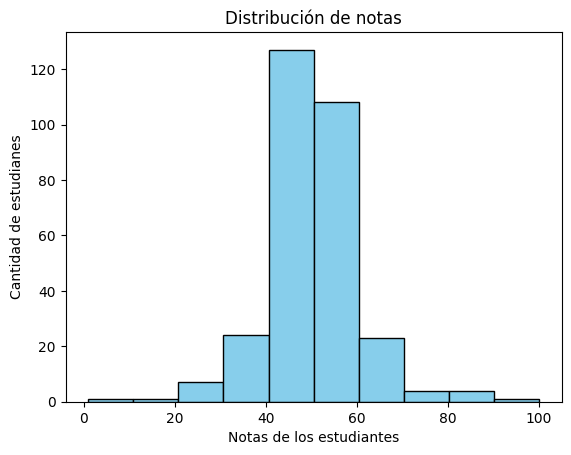

In [ ]:
# Histograma con Matplotlib

plt.hist(df["score"], bins=10, color="skyblue", edgecolor="black")

plt.xlabel("Notas de los estudiantes")
plt.ylabel("Cantidad de estudianes")
plt.title("Distribución de notas")

plt.show()

##### 2️⃣ Usando Seaborn

In [ ]:
# Seaborn hace gráficos más modernos y agradables a la vista.
# Además, permite agregar detalles adicionales sin complicarse.

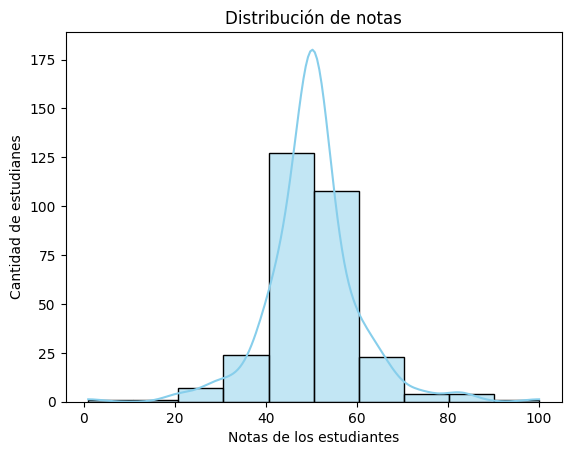

In [ ]:
# Histograma con Seaborn

sns.histplot(df["score"], bins=10, color="skyblue", kde=True)
#kde=True muestra una línea suave que sigue línea general delos datos

plt.xlabel("Notas de los estudiantes")
plt.ylabel("Cantidad de estudianes")
plt.title("Distribución de notas")

plt.show()

#### Errores comunes al construir e interpretar Histogramas

* Elegir mal el número de bins.
* Usar una escala muy larga en el eje X por los outliers.

¿Como evitar esto?

##### 1️⃣ Elegir correctamente el número de bins

El número de bins define en cuántos rangos se van a dividir tus datos.

* Pocos bins, el gráfico se vuelve demasiado simple: parece una sola montaña y esconde patrones.
* Muchos bins, aparecen muchos “dientes” y ruido visual: cuesta ver la forma de la distribución.

💡Recuerda: el objetivo es ver la forma real de la distribución.

In [ ]:
# 📌 Recomendación Práctica

# 1) Empieza con 10 bins
# 2) ¿Muy grueso, sin detalle? -> 15 bins / ¿Muy ruidoso, desordenado? -> 8 bins

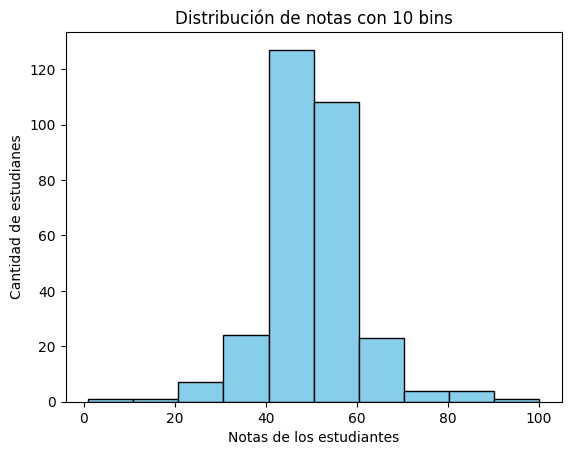

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/math_class.csv')



plt.hist(df["score"], bins=10, color="skyblue", edgecolor="black")

plt.xlabel("Notas de los estudiantes")
plt.ylabel("Cantidad de estudianes")
plt.title("Distribución de notas con 10 bins")

plt.show()

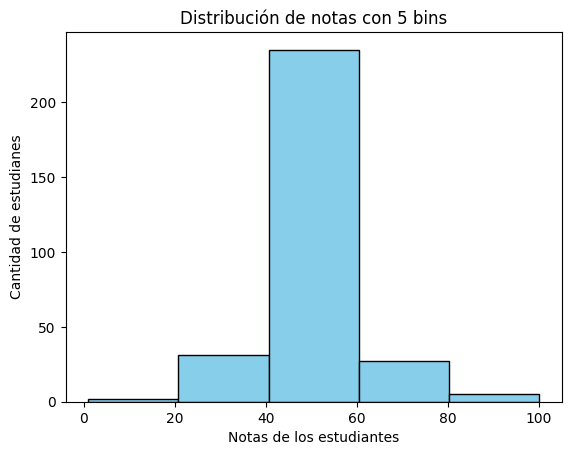

In [ ]:
plt.hist(df["score"], bins=5, color="skyblue", edgecolor="black")

plt.xlabel("Notas de los estudiantes")
plt.ylabel("Cantidad de estudianes")
plt.title("Distribución de notas con 5 bins")

plt.show()

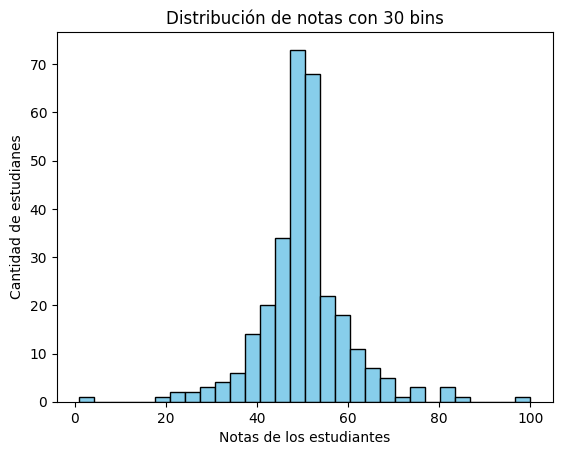

In [ ]:
plt.hist(df["score"], bins=30, color="skyblue", edgecolor="black")

plt.xlabel("Notas de los estudiantes")
plt.ylabel("Cantidad de estudianes")
plt.title("Distribución de notas con 30 bins")

plt.show()

💡 Otra opción para los bins es aplicar la regla de la raíz cuadrada, donde los bins son aproximadamente la raíz cuadrada del número de registros.

Ejemplo: Si tienes 900 datos →  √900 = 30  → ≈30 bins

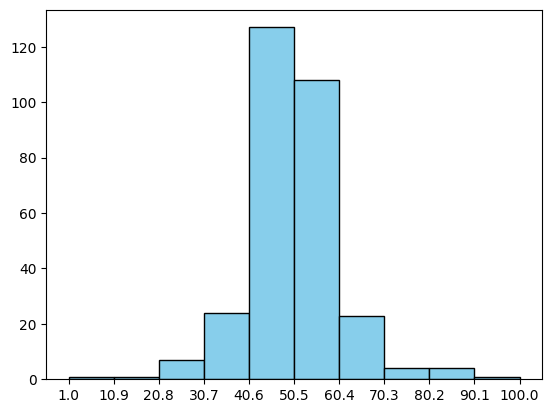

In [ ]:
# Muestra los límites reales de cada bin

counts, bin_edges, _ = plt.hist(df["score"], bins=10, color="skyblue", edgecolor="black")

# counts almacena cuantos datos caen dentro de cada barra
# bin_edges guarda los bordes reales de cada barra (valor de interés)
# _ indica que por ahora ignoramos el resto de valores, porque nos los necesitamos atm

plt.xticks(bin_edges) # usamos los bordes reales como etiquetas

plt.show()


##### 2️⃣ Ajustar la escala del eje X cuando hay outliers

Un error común al crear histogramas es no ajustar el eje X cuando existen outliers.

Si no lo haces:
* El eje se estira para incluir valores extremos.
* Las barras se ven muy bajas.
* Parece que todos los datos están en un solo bloque.

💡Antes de graficar, revisa mínimos, máximos y decide si necesitas acotar el rango.

In [ ]:
# 📌 Recomendación Práctica

# Primero revisa con describe() para identificar dónde se concentra la mayoría de los datos:

# Ese resumen muestra valores clave y uno de los más útiles para ajustar el eje X: el 75% (Q3)
# Q3 significa “El 75% de todos los precios está por debajo de este número”.
# Hasta ese punto están casi todos los valores y por encima suelen aparecer outliers.

# Usamos el valor del 75% como punto de referencia para decidir hasta dónde mostrar el eje X
# Por ejemplo:
# Si el 75% = 420 → corta en 500 o 600
# Si el 75% = 1,200 → corta en 1,500
# No es una regla exacta, lo importante es mostrar claramente donde está la mayoría de datos.

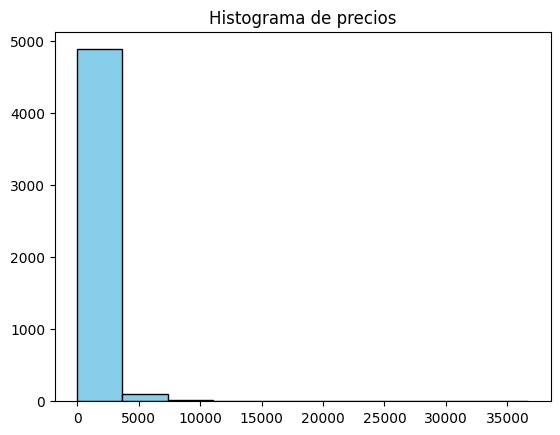

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/everpeak_clean.csv')

plt.hist(df["price"], bins=10, color="skyblue", edgecolor="black")
plt.title("Histograma de precios")
plt.show()

In [ ]:
df["price"].describe()

# El 75% de los precios son menores a 874.25 USD

count     5000.000000
mean       756.387400
std       1173.265182
min         12.000000
25%        218.000000
50%        457.000000
75%        847.250000
max      36708.000000
Name: price, dtype: float64

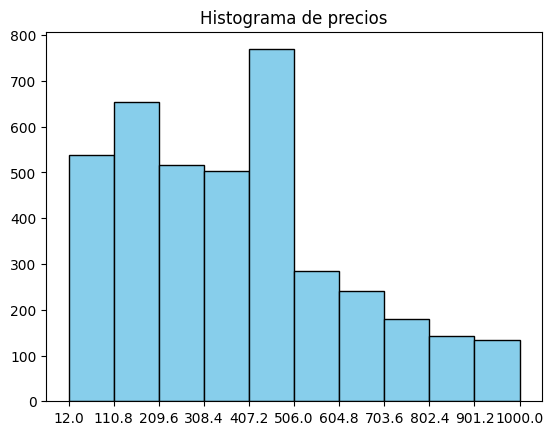

In [ ]:
counts,bin_edges,_= plt.hist(df["price"],bins=10,range=(12,1000),color="skyblue",edgecolor="black")
plt.xticks(bin_edges)
plt.title("Histograma de precios")
plt.show()

# Se ve sesgo hacia la derecha, con mayoría de datos entre 400 y 500 USD.

### Lección 7 - Explorando distribuciones con Boxplots e Histogramas

Los histogramas te permiten observar la forma general de una distribución: si es simétrica, si tiene colas largas o si hay valores concentrados en ciertos rangos.

Pero hay una pregunta clave que los histogramas no siempre responden bien:
* ¿Dónde están los outliers y qué tan lejos están del resto?

Aquí es donde entran los boxplots; esta herramienta es más potente para:
* Identificar outliers de forma inmediata
* Comparar distribuciones entre grupos
* Entender la dispersión sin necesidad de analizar números

Un boxplot resume una columna numérica y te permite ver:

* Dónde está la mayoría de los datos
* Qué tan dispersos están
* Si hay valores extremos (outliers)

#### ¿Qué partes tiene un boxplot?

1️⃣ La Mediana (Q2): La línea dentro de la caja te dice cuál es el “valor típico” de la columna.

2️⃣ La Caja: Representa el 50% central de los datos (entre Q1 y Q3)

* Q1: donde empieza la caja (25% de los datos)
* Q3: donde termina la caja (75% de los datos)
* La distancia entre Q1 y Q3 se llama Rango Intercuartil (IQR) y mide la dispersión de los datos.

3️⃣ Los Bigotes: Son las líneas que salen de la caja; muestran los valores que todavía se consideran normales.

4️⃣ Los Outliers: Son los puntos que están fuera de los bigotes; son los datos atípicos.

![image.png](attachment:image.png)

In [ ]:
# EJEMPLO - Usaremos el dataset prestamos_comunidad
# Nos enfocaremos en la columna monto_solicitado, que muestra los montos de dinero solicitados.

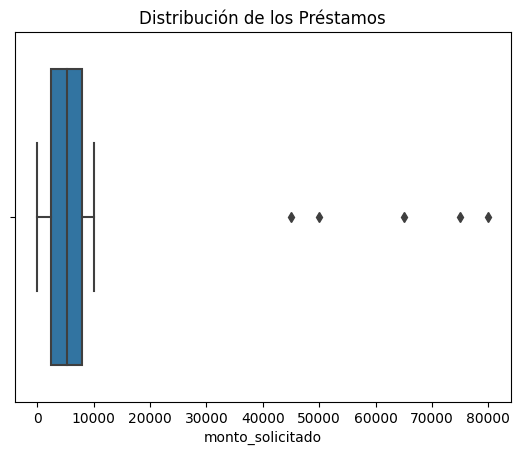

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/prestamos_comunidad.csv')

sns.boxplot(data=df, x='monto_solicitado')
plt.title('Distribución de los Préstamos')
plt.show()

* La mediana está en valores bajos, indicando que la mitad de los préstamos son montos pequeños.

* La caja (IQR) es estrecha: la mayoría de los préstamos están concentrados en un rango reducido.

* Los bigotes muestran el rango típico de valores sin considerar anomalías (0 - 10K).

* Los puntos aislados a la derecha son outliers altos (40K–80K), que revelan una cola derecha larga y préstamos excepcionalmente grandes.

#### Histogramas y boxplots para identificar visualmente sesgo, dispersión y valores atípicos

Hay tres patrones que aparecen una y otra vez en esos gráficos:

👉 Sesgo o skewness

👉 Dispersión o spread

👉 Valores atípicos / outliers

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

#### Demostración paso a paso: Visualizando order_value

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

df = pd.read_csv('/datasets/everpeak_clean.csv')

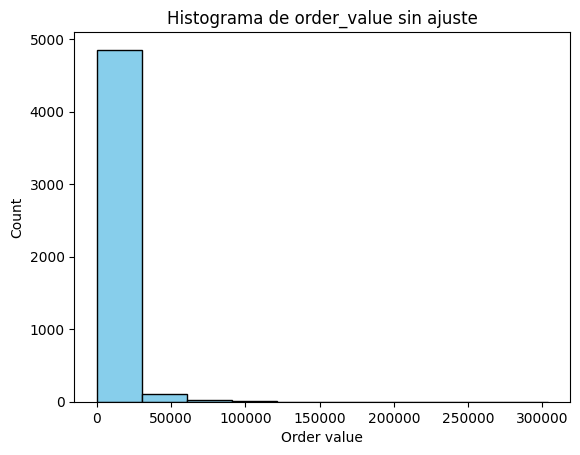

In [ ]:
# 1) Hisrograma con un número de bins

plt.hist(df['order_value'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histograma de order_value sin ajuste')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

# Sesgo hacia la derecha

In [ ]:
# 2) Revisar los valores con describe

df["order_value"].describe()

count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

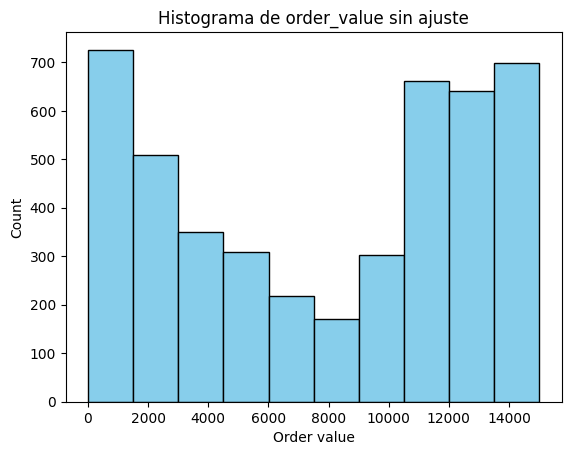

In [ ]:
# 3) Ajustar el eje X (hacer zoom en el rango útil)

plt.hist(df['order_value'], bins=10, range=(12,15000), color='skyblue', edgecolor='black')
plt.title('Histograma de order_value sin ajuste')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

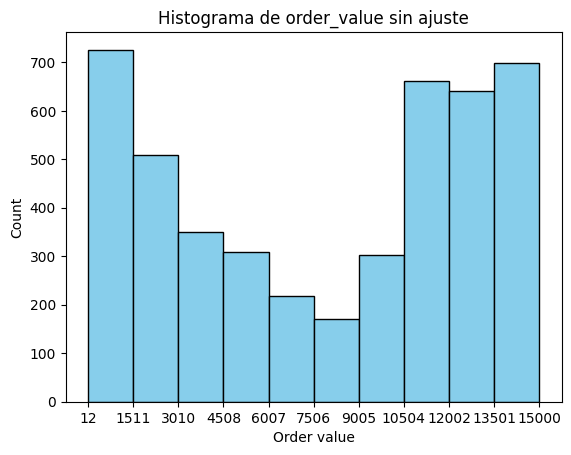

In [ ]:
# 4) Mostrar etiquetas de los rangos exactos

counts, bin_edges, _ = plt.hist(df['order_value'], bins=10, range=(12,15000), color='skyblue', edgecolor='black')

plt.xticks(bin_edges)

plt.title('Histograma de order_value sin ajuste')
plt.xlabel('Order value' )
plt.ylabel('Count')
plt.show()

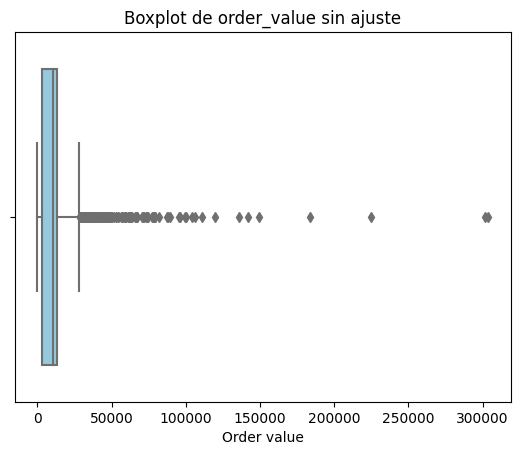

In [ ]:
# 5) Boxplot para ver outliers de forma directa

sns.boxplot(x=df["order_value"], color="skyblue")
plt.title('Boxplot de order_value sin ajuste')
plt.xlabel('Order value' )
plt.show()

# Distribución - Sesgo a la derecha
# Disperción baja (IQR)
# Outliers a la derecha

In [ ]:
# Aquí podrás ver:

# Si hay sesgo (si los bigotes son muy asimétricos).
# Qué tan amplios son los rangos de la caja (la dispersión IQR).
# Cuántos outliers están lejos del rango normal.

### Lección 9 - Entendiendo el signifcado de negocios de distribuciones

#### Tipos de Distribución

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

#### Cómo conectar la forma de la distribución con fenómenos de ventas al por menor (Retail)


In [ ]:
# Importamos data set y cargamos librerias

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

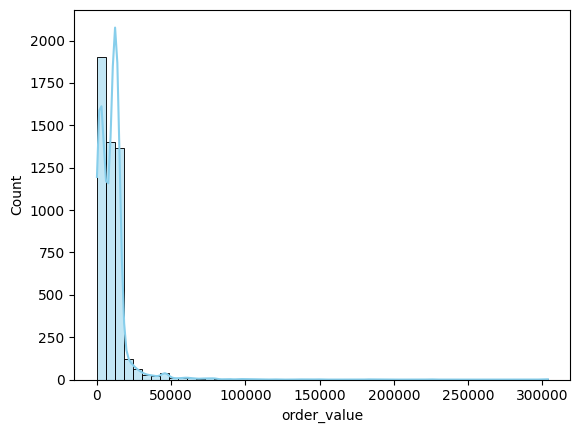

In [ ]:
# Visualizando order_value
sns.histplot(df["order_value"], bins=50, color="skyblue", kde=True)
plt.show()

# Sesgo hacia la derecha
# La mayoría de los clientes hace compras pequeñas o moderadas
# Hay un grupo pequeño de cliente que son de alto-gasto (pocos, pero pueden generar parte importante)

1) order_value : Detectar clientes de alto gasto (“whales”)

El histograma está sesgado a la derecha: la mayoría de pedidos son pequeños, pero unos pocos muy grandes elevan el promedio.

💡Interpretación de negocio:

* Existen unos pocos clientes “whales” (de alto valor).
* Son ideales para programas premium o retención personalizada.
* Conviene validarlos para descartar si son compras corporativas o errores.

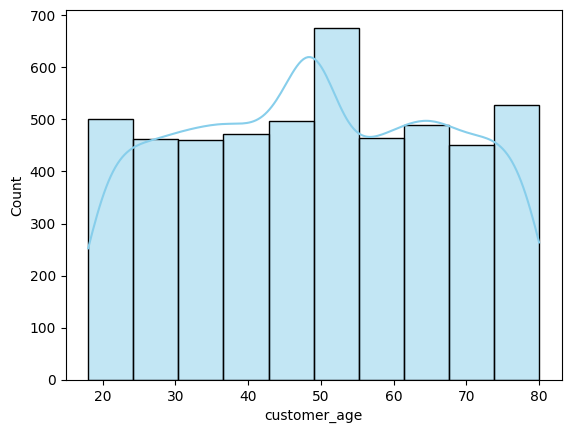

In [ ]:
# Visualizando customer_age
sns.histplot(df["customer_age"], bins=10, color="skyblue", kde=True)
plt.show()

# Distribución que no es normal ni sesgada a los datos.
# Distribución uniforme entre las edades, con un pico entre los 50 y 55 años.
# En el cliente típico, no predominan edades jóvenes o avanzadas, con excepción del seg.dominante

2) customer_age : Detectar el segmento dominante

La curva muestra un comportamiento casi uniforme, excepto por un pico notable entre los 50 y 55 años.

No es una distribución normal, ni está sesgada: solo tiene un segmento claramente dominante.

💡Interpretación de negocio:

* El cliente típico no tiene una edad joven ni avanzada, pero hay un segmento destacado de adultos entre 50 y 55 años.
* Sin embargo, existe una base diversa, útil para campañas diferenciadas por edad.

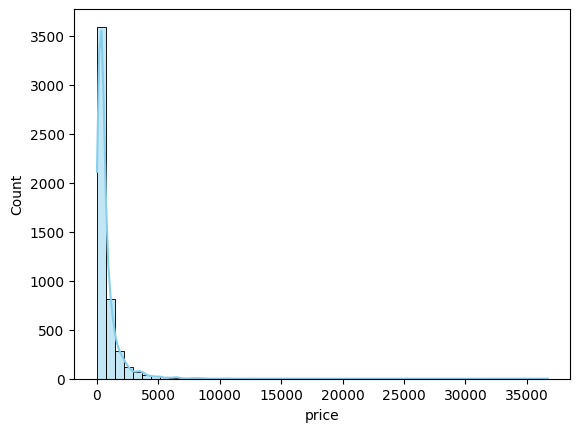

In [ ]:
# Visualizando price
sns.histplot(df["price"], bins=50, color="skyblue", kde=True)
plt.show()

# Mayoría de productos tienen precios bajos o medios
# La tienda tiene una pequeña selección de productos premium (gama alta)
# Esa mezcla puede ser estratégica para atraer distintos tipos de clientes

3) price : Mezcla de productos básicos y premium

La mayor parte de los precios están concentrados en valores bajos o medios, pero existe una pequeña porción de productos con precios muy altos. Esto genera una cola hacia la derecha.

💡Interpretación de negocio:

* EverPeak ofrece productos accesibles, de alta rotación.
* También incluye algunos productos premium, que elevan la cola y pueden atraer a clientes con mayor poder adquisitivo.
* Esta combinación es útil para estrategias de segmentación por precio.

## Chapter 3 - Análisis de valores atípicos y segmentación

### Lección 1 - Identificando valores atípicos con reglas estadísticas


Como ya lo venimos estudiando, un outlier o valor atípico es un valor que se aleja drásticamente del patrón general de la distribución.

Puede representar:

* Errores de captura (cantidad = -2, precio negativo)
* Eventos raros pero reales (clientes de alto valor)
* Fraude o anomalías operativas
* Diferencias reales de comportamiento

👉 Detectarlos no implica eliminarlos automáticamente.

👉 Métodos estadísticos mas avanzados para evitar subjetividad a la hora de identificar y tratar outliers:

#### 📏 Método 1 — Rango intercuartílico (IQR)

Los extremos se definen como:

* Extremo inferior = Q1 − 1.5 × IQR
* Extremo superior = Q3 + 1.5 × IQR

In [ ]:
# Calcular IQR en Python

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/datasets/everpeak_clean.csv").head(50)

# 📌 Usaremos los primeros 50 datos de la columna price para interpretar mejor
# los datos de EverPeak, pero normalmente se toma toda la columna.

In [ ]:
# Calcular Q1
Q1 = df["price"].quantile(0.25)
print("Primer Quartil: ", Q1)

# Calcular Q3
Q3 = df["price"].quantile(0.75)
print("Tercer Quartil: ", Q3)

Primer Quartil:  267.25
Tercer Quartil:  580.0


In [ ]:
# Calcular IQR
IQR = Q3 - Q1
print("IQR: ", IQR)

IQR:  312.75


In [ ]:
# Calcular Límite Inferior
lower = Q1 - 1.5*IQR
print("Límite inferior: ", lower)

# Calcular Límite Superior
upper = Q3 + 1.5*IQR
print("Límite superior: ", upper)

Límite inferior:  -201.875
Límite superior:  1049.125


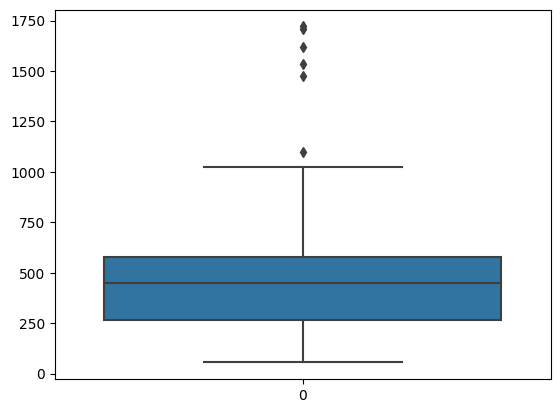

In [ ]:
# Boxplot
sns.boxplot(data=df["price"])
plt.show()

¿Cuándo usar IQR?
* Cuando el dataset está sesgado (right-skewed).
* Cuando necesitas una regla robusta frente a sesgo y valores extremos.

Limitación
* El método tiende a marcar muchos valores como outliers cuando la distribución está muy sesgada (como price en EverPeak).
* No funciona bien si la distribución tiene múltiples modas (bimodal).

#### 📊 Método 2 — Z-Score (puntuación estándar)


El Z-Score indica cuántas desviaciones estándar está un dato por encima o por debajo de la media (promedio).

Fórmula: z = (x - mean) / std

💡Regla típica: |z| > 3 → posible outlier.

In [ ]:
# Calcular Z-Score en Python

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/datasets/everpeak_clean.csv").head(50)

# 📌 Usaremos los primeros 50 datos de la columna price para interpretar mejor
# los datos de EverPeak, pero normalmente se toma toda la columna.

In [ ]:
# Calculamos media
mean = df["price"].mean()

# Calculamos desviación estándar
std = df["price"].std()

In [ ]:
# Creamos columna Z con el score
df["z"] = (df["price"] - mean)/std

In [ ]:
# Vemos registros donde el valor Z dl precio sea mayor a 3
df[df["z"].abs() > 3]

# filtrar para ver registros
# Si NO obtenemos registros, ninguno pasó el criterio, por lo que no hay valores extremos

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,z


In [ ]:
# Verificamos
df["z"].describe()

count    5.000000e+01
mean    -1.176836e-16
std      1.000000e+00
min     -1.102801e+00
25%     -6.150952e-01
50%     -1.940253e-01
75%      1.035384e-01
max      2.725316e+00
Name: z, dtype: float64

El Umbral Clásico (Regla Empírica)

* En el análisis de datos, se utiliza una regla empírica derivada de la distribución normal, la Regla 68-95-99.7 para definir los outliers que establece que:

* Aproximadamente el 95% de los datos caen dentro de 2 desviaciones estándar.
* Aproximadamente el 99.7% de los datos caen dentro de 3 desviaciones estándar.
* Por lo tanto, el umbral de outlier más común es |Z| > 3

¿Cuándo usar z-score?

* Cuando la distribución es aproximadamente normal.
* Cuando no hay colas extremadamente largas.


Limitación
*  En distribuciones right-skewed, la media y la desviación estándar se distorsionan, por lo que: 👉 El z-score sub-detecta outliers reales.

En el dataset de EverPeak, este método falla parcialmente en price debido a sus outliers.

#### 🧪 Demostración paso a paso con EverPeak (customer_age)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/datasets/everpeak_clean.csv")
df["customer_age"].describe()

count    5000.000000
mean       49.120800
std        17.710679
min        18.000000
25%        34.000000
50%        49.000000
75%        64.000000
max        80.000000
Name: customer_age, dtype: float64

In [ ]:
# Q1, Q3 e IQR

Q1 = df["customer_age"].quantile(0.25)
Q3 = df["customer_age"].quantile(0.75)
IQR = Q3 - Q1

print("Cuartil 1: ", Q1)
print("Cuartil 3: ", Q3)
print("IQR: ", IQR)

Cuartil 1:  34.0
Cuartil 3:  64.0
IQR:  30.0


In [ ]:
# Límites

upper = Q3 + 1.5*IQR
df[df["customer_age"] > upper].head()

lower = Q1 - 1.5*IQR
df[df["customer_age"] < lower].head()

# Filtramos para ver si algún valor está por encima o por debajo de los límites

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag


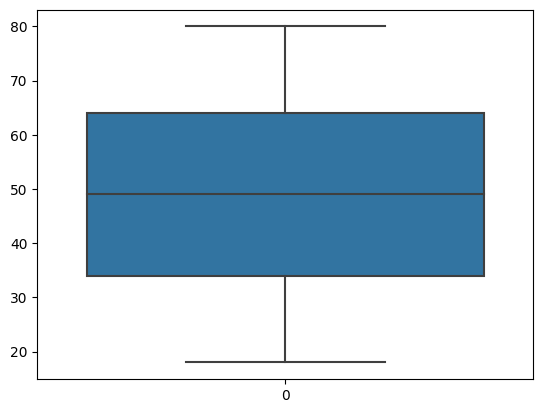

In [ ]:
# Boxplot

sns.boxplot(data=df["customer_age"])
plt.show()

In [ ]:
# Verificamos utilizando método Z-Score

df["z"] = (df["customer_age"] - df["customer_age"].mean())/df["customer_age"].std()

df[df["z"].abs() > 3]

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,z


#### 🥊 Comparación directa: IQR vs. Z-score

![image.png](attachment:image.png)

![image-2.png](attachment:image-2.png)

### Lección 2 - Cómo abordar valores atípicos según el contexto

🏁 Introducción — No todos los outliers deben eliminarse

👉 Detectarlos es fácil. Decidir qué hacer con ellos es lo difícil.

El equipo de Estrategia e Integración de EverPeak necesita claridad sobre estos valores atípicos o extremos porque pueden reflejar:

* Clientes VIP de alto valor
* Errores de captura
* Fraude o transacciones anómalas
* Patrones reales del retail (colas largas)


Ahora tu responsabilidad es entender el contexto, evaluar si la distribución es naturalmente asimétrica (skewed) y tomar decisiones informadas:

* ¿Eliminar los valores?
* ¿Corregirlos?
* ¿Conservarlos?
* ¿Capar los valores extremos (winsorización)?

#### 1. 🤔 ¿Cuándo un outlier es un problema… y cuándo no?

In [ ]:
# Antes de aplicar cualquier técnica, pregúntate:
# ¿Cuál es la distribución de cada variable numérica?

import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

print("Medianas")
print(df.median())

print(df[["price", "quantity", "order_value", "customer_age"]].describe())

Medianas
order_id                  2500.5
customer_id               1988.0
price                      457.0
quantity                    14.0
order_value              10341.0
customer_age                49.0
quantity_invalid_flag        1.0
age_invalid_flag             0.0
state_missing_flag           0.0
dtype: float64
              price     quantity    order_value  customer_age
count   5000.000000  5000.000000    5000.000000   5000.000000
mean     756.387400    32.359800   10075.523800     49.120800
std     1173.265182    93.403826   12406.603152     17.710679
min       12.000000     1.000000      12.000000     18.000000
25%      218.000000     7.000000    3094.000000     34.000000
50%      457.000000    14.000000   10341.000000     49.000000
75%      847.250000    23.000000   13160.500000     64.000000
max    36708.000000  2083.000000  303824.000000     80.000000


In [ ]:
# price, quantity y order_value
# Distribuciones sesgadas a la derecha (right-skewed).
# Valores atípicos altos, visibles en los máximos muy por encima del percentil 75.
# Medias superiores a las medianas, lo que indica que los valores extremos influyen en el promedio.

In [ ]:
# customer_age
# Distribución más estable y acotada (18 a 80 años).
# Media y mediana prácticamente iguales.
# Los valores extremos tienen poco impacto en las métricas centrales.

#### 2. 🧭 Cuándo mantener, eliminar o capar outliers

![image.png](attachment:image.png)

#### 🛠️ ¿Qué es la Winsorización?

![image.png](attachment:image.png)

In [ ]:
# Aplicar Cap / Winsodirzación

import pandas as pd
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")
df["order_value"].describe()

count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

In [ ]:
# Percentile 1 - Umbral inferior de capado

lower = df["order_value"].quantile(0.01)
lower

192.0

In [ ]:
# Percentile 99 - Umbrar superior de capado

upper = df["order_value"].quantile(0.99)
upper

56150.67000000012

In [ ]:
# Reemplazo de valores con Numpy
# np.clip(df[columna], límite inferior, límite superior)
# La función fuerza a quedar dentro de estos límites

df["order_value_winsor"] = np.clip(df["order_value"], lower, upper)
df[["order_value", "order_value_winsor"]].head()

,order_value,order_value_winsor
0,13385,13385.0
1,660,660.0
2,5073,5073.0
3,14290,14290.0
4,11754,11754.0


In [ ]:
# Validación

df[["order_value", "order_value_winsor"]].describe()

,order_value,order_value_winsor
count,5000.000000,5000.000000
mean,10075.523800,9695.544500
std,12406.603152,8676.466743
min,12.000000,192.000000
25%,3094.000000,3094.000000
50%,10341.000000,10341.000000
75%,13160.500000,13160.500000
max,303824.000000,56150.670000


#### 4. 🧪 Flujo práctico: Detección + Decisión

In [ ]:
# Paso 1 — Detecta outliers (IQR o z-score)

Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = df[df["order_value"] > upper]

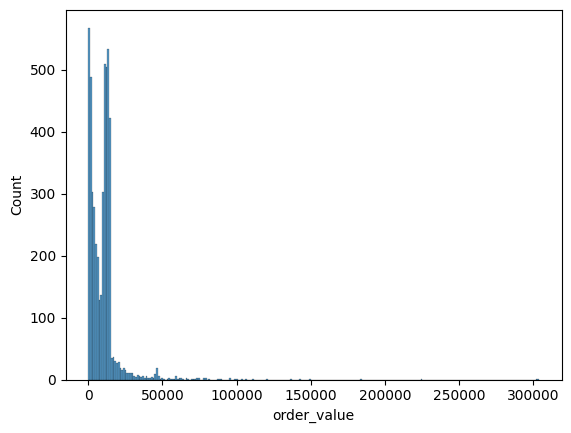

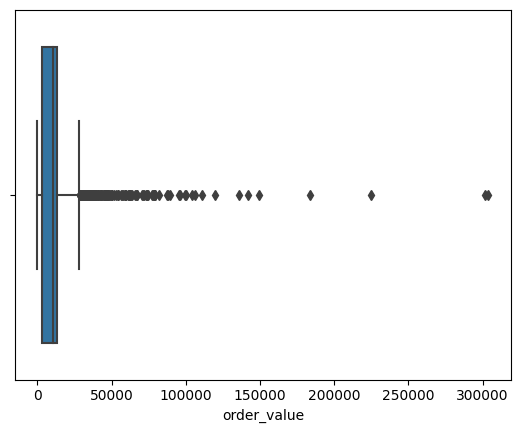

In [ ]:
# Paso 2 — Examina visualmente

sns.histplot(df['order_value'])
plt.show()

sns.boxplot(x=df['order_value'])
plt.show()

In [ ]:
# Paso 3 — Decide según el contexto

![image.png](attachment:image.png)

#### Conclusión

Aprendizaje central

👉 No existe una receta única.

👉 La intención del dato (error vs. comportamiento real) es más importante que su magnitud.

👉 Winsorización (Winsorization) es una herramienta poderosa cuando no quieres eliminar datos reales.

### Lección 4 - Segmentación de clientes con sentencias if

🏁 Introducción: Lógica y reglas de negocio
   
Falta dar un paso fundamental para convertir datos crudos en información útil para el negocio:

👉 Crear nuevas columnas basadas en reglas, lógica de negocio o combinaciones de variables.

A esta habilidad se le conoce como **Feature Engineering**, una de las capacidades más importantes para cualquier analista de datos.

¿Por qué es crucial? Porque los datasets reales casi nunca vienen listos para responder preguntas urgentes del negocio. Los analistas deben transformar los datos para revelar:

* Segmentos de clientes.
* Indicadores de riesgo.
* Niveles de valor.
* Y relaciones significativas.

####  🧠 1. El Pilar de la Lógica: if/elif/else en Python

In [ ]:
# EJEMPLO: Clasificar una Venta

valor_venta = 75

# Si la venta es mayor a 100, imprime "Venta Alta"
if valor_venta >= 100:
    print("Venta alta")
# Caso contrario, imprime "Venta Baja"
else:
    print("Venta baja")
print("Valor:", valor_venta)
print("\nCódigo terminado")

Venta baja
Valor: 75

Código terminado


In [ ]:
# EJEMPLO: Clasificar la puntuación de un producto (MÚLTIPLES CONDICIONES)

puntuacion = 5.5

if puntuacion >= 9:
    clasificacion = "Excelente"
elif puntuacion >= 7:
    clasificacion = "Buena"
elif puntuacion >= 5:
    clasificacion = "Regular"
else:
    clasificacion = "Mala"

print(clasificacion)

Regular


![image.png](attachment:image.png)

In [ ]:
# EJEMPLO - Clasificar comentario

comentario = "BUENO"

if comentario.lower() == "excelente":
    clasificacion = 100
elif comentario.lower() == "bueno":
    clasificacion = 80
elif comentario.lower() == "regular":
    clasificacion = 60
else:
    clasificacion = 40

print(f"El comentario:'{comentario.lower()}' tiene clasificación de {clasificacion}.")

# f-string usa comillas dobles, por lo que usamos comillas simples en {comentario.lower()}
# para evitar confusiones o malinterpretaciones en Python

El comentario:'bueno' tiene clasificación de 80.


#### 2. Caso de Estudio: Segmentando clientes de EverPeak

💡 Consejo de orden: Es una buena práctica ordenar las condiciones por prioridad, o de la más restrictiva a la menos restrictiva, para asegurar que los casos especiales (como manejar errores o VIPs) se capturen primero.

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

In [ ]:
# Calculamos promedio "customer_age"

edad_promedio = df["customer_age"].mean()
print("Edad promedio:", edad_promedio)

Edad promedio: 49.1208


In [ ]:
# Clasificar clientes si la edad promedio es mayor (o menor o igual) a 55

if edad_promedio > 55:
    print("Clientes senior")
else:
    print("Clientes junior")

Clientes junior


In [ ]:
# Calculamos promedio "order_value" (gasto_promedio)

gasto_promedio = df["order_value"].mean()
print("Gasto promedio:", gasto_promedio)

Gasto promedio: 10075.5238


In [ ]:
# Clasificar clientes según elgasto promedio

if gasto_promedio > 10000:
    print("Clientes: VIP")
elif gasto_promedio > 5000:
    print("Clientes: Medium Value")
else:
    print("Clientes: Low Value")

Clientes: VIP


### Lección 6 - Segmentación para el análisis de clientes

#### 🧠 Feature Engineering

La ingeniería de características (Feature Engineering) consiste en crear, transformar o combinar columnas para que el análisis o un modelo entiendan mejor el comportamiento del negocioo

Ejemplos comunes:

* Crear categorías a partir de rangos numéricos (edad → “jóvenes”, “adultos”).
* Sumar transacciones individuales para calcular gasto anual.
* Crear indicadores (flags).
* Combinar columnas para generar ratios (ingresos/visitas).

Estas nuevas columnas no existían originalmente, pero permiten revelar patrones clave.


#### 🧩 ¿Por qué es tan importante en análisis?

* Revelar comportamientos escondidos.
* Simplificar análisis y comparaciones.
* Segmentar clientes.
* Preparar datos para modelos predictivos.

Convierte columnas dispersas en insights accionables, y es una de las habilidades más valiosas del análisis moderno.

#### 🏬Caso EverPeak: de datos crudos a clientes clasificados


En nuestro dataset, cada fila representa una orden individual: edad del cliente, valor del pedido, etc.

Pero ninguna columna indica el tipo de cliente.

El equipo de estrategia e integración necesita saber:

* ¿Cuántos clientes son Senior VIP?
* ¿Cuáles aportan la mayoría de la ganancia?
* ¿Qué segmentos muestran más outliers?
* ¿Dónde están las oportunidades de retención?

Debemos crear una nueva característica:

👉 Un segmento de cliente basado en edad y gasto (clasificar según características y comportamiento)

![image.png](attachment:image.png)

#### ✨ Crear la columna de segmentación: sin función vs. con función

##### A) Método 1 — Crear columna sin función

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")

In [ ]:
df["customer_segment"] = np.where(
    (df["customer_age"] >= 55) & (df["order_value"] >= 10000), "Senior VIP",
        np.where((df["customer_age"] < 55) & (df["order_value"] >= 10000), "Junior VIP",
            np.where((df["customer_age"] >= 55) & (df["order_value"] >= 5000), "Sr. Medium Value",
                np.where((df["customer_age"] < 55) & (df["order_value"] >= 5000), "Jr. Medium Value",
                    np.where(df["order_value"] < 5000, "Low Value", "Error")
                        )
                    )
                )
)

df[["customer_age", "order_value", "customer_segment"]].head(10)
#💡 where es útil cuando la lógica es simple y hay pocas condiciones.

,customer_age,order_value,customer_segment
0,66,13385,Senior VIP
1,24,660,Low Value
2,23,5073,Jr. Medium Value
3,70,14290,Senior VIP
4,75,11754,Senior VIP
5,57,13347,Senior VIP
6,75,10868,Senior VIP
7,38,2862,Low Value
8,40,45819,Junior VIP
9,28,23940,Junior VIP


##### B) Método 2 — Crear columna con función personalizada

💡 Ordenamos las condiciones de mayor a menor prioridad, para evitar que un VIP sea capturado por reglas inferiores.

![image.png](attachment:image.png)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")

In [ ]:
# Función SIMPLE

def classify_segment(row):
    return "otro"

# Aplicar función y ver cambios

df["customer_segment"] = df.apply(classify_segment, axis=1)    #axis=1 ejecuta fila por fila
df[["customer_age", "order_value", "customer_segment"]].head()

,customer_age,order_value,customer_segment
0,66,13385,otro
1,24,660,otro
2,23,5073,otro
3,70,14290,otro
4,75,11754,otro


In [ ]:
# Función + Apply + Condiciones

def classify_segment(row):
    age = row["customer_age"]
    spend = row["order_value"]

    # Manejo de nulos o faltantes (dentro de la función)
    if pd.isna(age) or pd.isna(spend):
        return "Error de Datos"

    # Segmentación de ALTO VALOR (dentro de la función)
    if spend >= 10000:
        if age >= 55:
            return "Senior VIP"
        else: # age < 55
            return "Junior. VIP"

    # Segmentación de MID VALUE (dentro de la función)
    elif spend >= 5000:
        if age >= 55:
            return "Senior Medium Value"
        else: # age < 55
            return "Junior Medium Value"

    # Segmentación de LOW VALUE (dentro de la función)
    else: # spend < 5000
        return "Low Value"

# Aplicar función y ver cambios

df["customer_segment"] = df.apply(classify_segment, axis=1)    #axis=1 ejecuta fila por fila
df[["customer_age", "order_value", "customer_segment"]].head()

,customer_age,order_value,customer_segment
0,66,13385,Senior VIP
1,24,660,Low Value
2,23,5073,Junior Medium Value
3,70,14290,Senior VIP
4,75,11754,Senior VIP


![image.png](attachment:image.png)

### Lección 9 - Redacción de un resumen estadístico

🏁 Introducción — ¿Qué es un Statistical Summary?

Un resumen estadístico o Statistical Summary es un informe corto, técnico, pero interpretativo que documenta:

* Cómo es la distribución de cada variable relevante.
* Qué outliers aparecen y si tienen sentido para el negocio.
* Qué tratamiento aplicaste (drop, cap, keep).
* Cómo impactó ese tratamiento en las estadísticas finales.

👉 El objetivo no es “limpiar por limpiar”, es justificar analíticamente cada decisión.

Escribir un buen Statistical Summary implica entender **cuándo un valor extremo tiene sentido** y cuándo no, **justificar por qué se toman ciertas decisiones** y explicar la naturaleza de los datos usando un enfoque estadístico.

#### 🧭  ¿Qué preguntas responde un buen Statistical Summary?

![image.png](attachment:image.png)

#### 🧱 La estructura recomendada (plantilla)

In [ ]:
# Importar librerías y dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")

In [ ]:
# 1) Visión general

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   order_id               5000 non-null   int64 
 1   order_date             5000 non-null   object
 2   customer_id            5000 non-null   int64 
 3   product_category       5000 non-null   object
 4   price                  5000 non-null   int64 
 5   quantity               5000 non-null   int64 
 6   order_value            5000 non-null   int64 
 7   payment_method         5000 non-null   object
 8   city                   5000 non-null   object
 9   state                  5000 non-null   object
 10  customer_age           5000 non-null   int64 
 11  quantity_invalid_flag  5000 non-null   int64 
 12  age_invalid_flag       5000 non-null   int64 
 13  state_missing_flag     5000 non-null   int64 
 14  customer_segment       5000 non-null   object
dtypes: int64(9), object(6

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,customer_segment
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0,Senior VIP
1,2,2024-10-10,1736,Grocery,66,10,660,debit_card,Los Angeles,CA,24,1,0,0,Low Value
2,3,2024-08-27,2543,Sports,267,19,5073,credit_card,Chicago,IL,23,1,0,0,Junior Medium Value
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0,Senior VIP
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75,0,0,0,Senior VIP


* Las columnas price, quantity, order_value y customer_age son de tipo INT
* Las analizamos porque permiten identificar patrones, distribuciones, valores atípicos útiles para el análisis

In [ ]:
# 2) Estadísticas descriptivas

num_cols = ["price","quantity","order_value","customer_age"]
df[num_cols].describe()

,price,quantity,order_value,customer_age
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,756.387400,32.359800,10075.523800,49.120800
std,1173.265182,93.403826,12406.603152,17.710679
min,12.000000,1.000000,12.000000,18.000000
25%,218.000000,7.000000,3094.000000,34.000000
50%,457.000000,14.000000,10341.000000,49.000000
75%,847.250000,23.000000,13160.500000,64.000000
max,36708.000000,2083.000000,303824.000000,80.000000


In [ ]:
# 3) Visualización diagnóstica

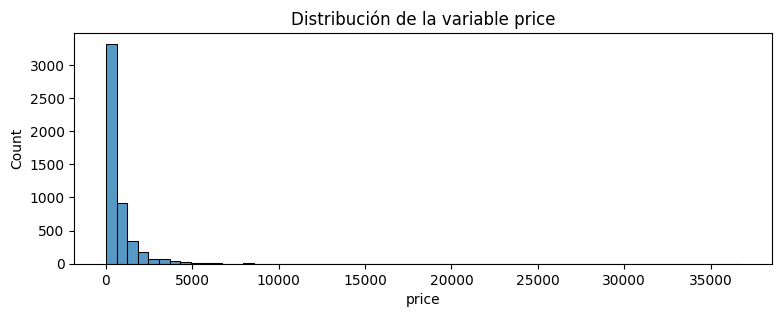

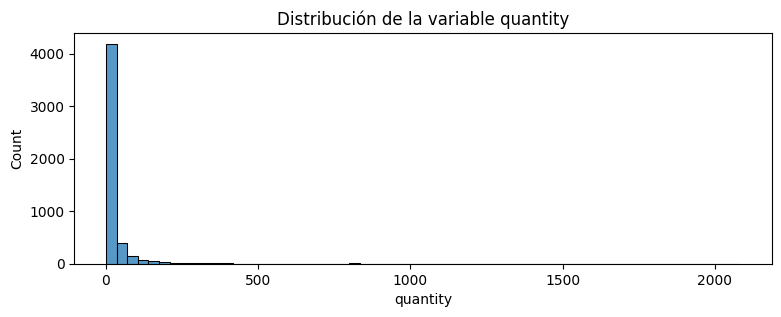

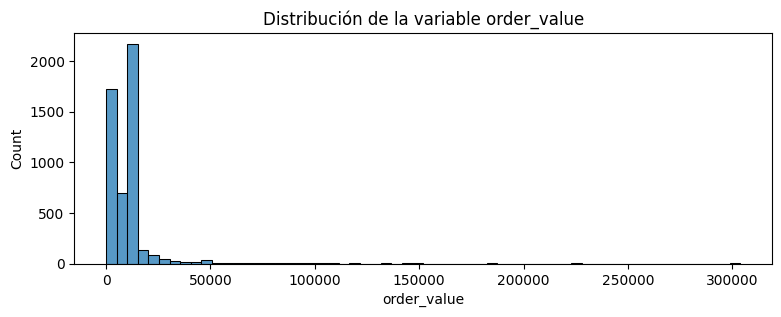

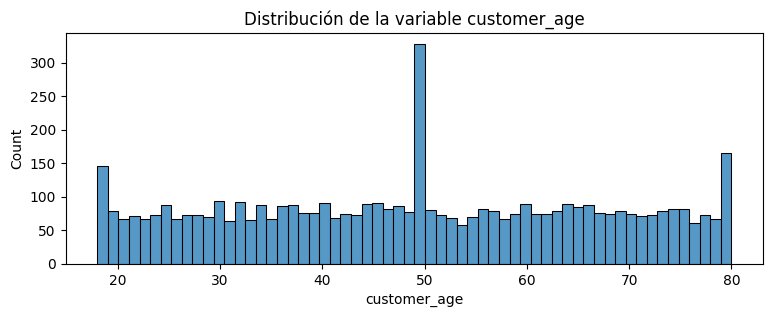

In [ ]:
# Graficar histogramas

for col in num_cols:
    plt.figure(figsize = (9, 3))
    sns.histplot(df[col], bins=60)
    plt.title(f'Distribución de la variable {col}')
    plt.show()

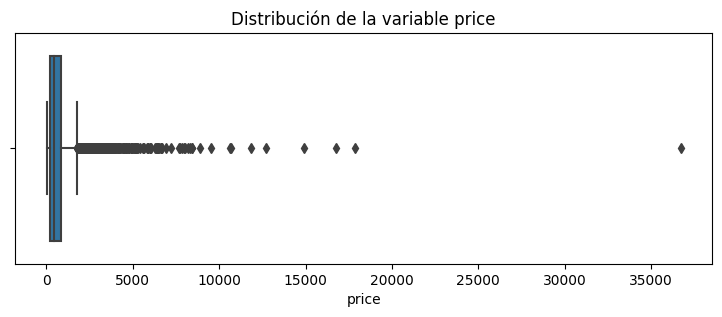

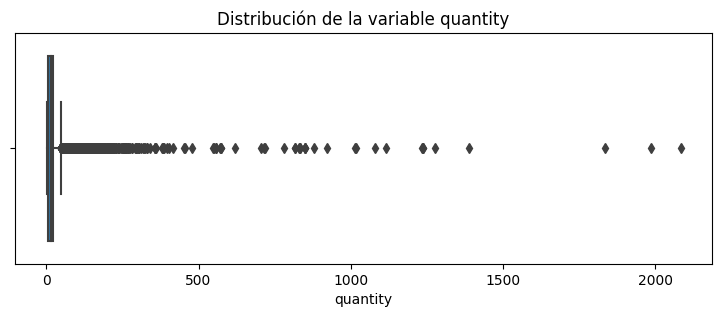

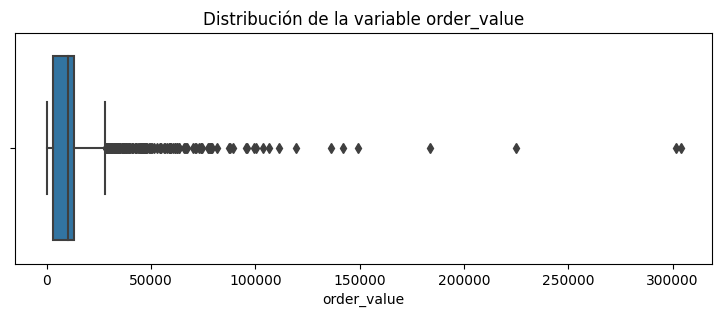

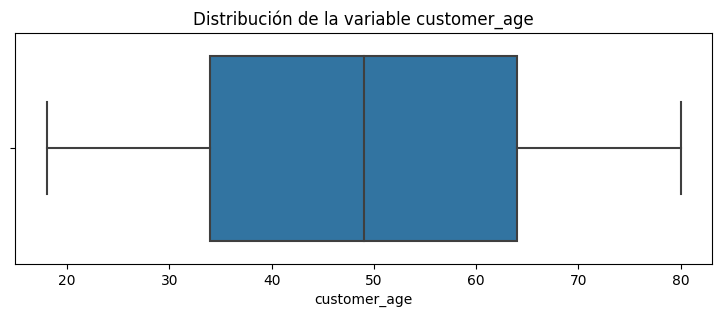

In [ ]:
# Graficar boxplots

for col in num_cols:
    plt.figure(figsize = (9, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de la variable {col}')
    plt.show()

En price, quantity y customer_value se detectan valores atípicos hacia la derecha, en customer_age, no.

In [ ]:
# 4) Identificación formal de outliers

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(col, "IQR: ", IQR)

    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    display(df[(df[col] > upper) | (df[col] < lower)])

price IQR:  629.25


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,customer_segment
64,65,2024-05-30,1651,Sports,2106,5,11155,debit_card,Phoenix,AZ,66,0,0,0,Senior VIP
67,68,2024-05-15,2385,Home,5181,4,20724,debit_card,Miami,FL,32,1,0,0,Junior. VIP
95,96,2024-04-15,2991,Sports,1940,4,7760,credit_card,New York,NY,40,1,0,0,Junior Medium Value
123,124,2024-06-21,1389,Electronics,1947,16,31152,debit_card,Boston,MA,45,1,0,0,Junior. VIP
138,139,2024-05-07,2274,Electronics,2437,6,14481,credit_card,Denver,CO,56,0,0,0,Senior VIP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4955,4956,2024-03-11,2230,Electronics,3824,6,22944,debit_card,unknown,unknown,52,1,0,1,Junior. VIP
4974,4975,2024-10-20,2627,Electronics,1985,6,12454,debit_card,New York,NY,72,0,0,0,Senior VIP
4984,4985,2024-03-11,2509,Sports,1911,4,7644,credit_card,Miami,FL,36,1,0,0,Junior Medium Value
4990,4991,2024-08-25,2569,Sports,2856,5,14616,credit_card,Los Angeles,CA,74,0,0,0,Senior VIP


quantity IQR:  16.0


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,customer_segment
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0,Senior VIP
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0,Senior VIP
8,9,2024-03-14,2925,Beauty,55,833,45819,credit_card,Boston,MA,40,0,0,0,Junior. VIP
29,30,2024-06-11,2562,Grocery,69,202,13914,credit_card,San Francisco,CA,56,0,0,0,Senior VIP
34,35,2024-11-20,2614,Grocery,159,72,11510,paypal,San Francisco,CA,67,0,0,0,Senior VIP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,4951,2024-04-30,2918,Beauty,37,383,14189,credit_card,Los Angeles,CA,59,0,0,0,Senior VIP
4959,4960,2024-12-11,2325,Beauty,138,95,13092,credit_card,New York,NY,77,0,0,0,Senior VIP
4971,4972,2024-05-20,2301,Beauty,178,79,14027,credit_card,Phoenix,AZ,71,0,0,0,Senior VIP
4977,4978,2024-02-10,1469,Toys,158,77,12127,credit_card,San Francisco,CA,66,0,0,0,Senior VIP


order_value IQR:  10066.5


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,customer_segment
8,9,2024-03-14,2925,Beauty,55,833,45819,credit_card,Boston,MA,40,0,0,0,Junior. VIP
123,124,2024-06-21,1389,Electronics,1947,16,31152,debit_card,Boston,MA,45,1,0,0,Junior. VIP
155,156,2024-08-30,2901,Grocery,36,1278,45998,credit_card,Miami,FL,32,0,0,0,Junior. VIP
199,200,2024-12-18,2919,Fashion,5174,7,36218,credit_card,Los Angeles,CA,24,1,0,0,Junior. VIP
265,266,2024-07-31,1905,Electronics,2897,10,28970,paypal,Miami,FL,31,1,0,0,Junior. VIP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4934,4935,2024-05-19,1502,Electronics,4282,11,47102,credit_card,Seattle,WA,47,1,0,0,Junior. VIP
4936,4937,2024-12-17,1907,Home,1522,19,28918,credit_card,New York,NY,48,1,0,0,Junior. VIP
4942,4943,2024-11-02,1979,Electronics,6478,11,71258,debit_card,Seattle,WA,49,1,1,0,Junior. VIP
4947,4948,2024-07-09,1447,Beauty,45,1015,45697,credit_card,Seattle,WA,37,0,0,0,Junior. VIP


customer_age IQR:  30.0


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag,customer_segment


In [ ]:
# 5) Clasificación y tratamiento de outliers - Drop, Keep o Cap

# Drop: cuando el valor es imposible
# Keep: cuando representa clientes VIP
# Winsorization: cuando es extremo pero posible

In [ ]:
# 5.1) Winsorización (valores extremos pero posibles)
# Para consevar información del cliente típico, capamos valores por centima del percentil 99

for col in num_cols:
    p99 = df[col].quantile(0.99)
    df[f'{col}_caped'] = np.clip(df[col], None, p99)

df[["price","price_caped","quantity","quantity_caped","order_value","order_value_caped",
    "customer_age","customer_age_caped"]].head()

,price,price_caped,quantity,quantity_caped,order_value,order_value_caped,customer_age,customer_age_caped
0,269,269.0,50,50.0,13385,13385.0,66,66
1,66,66.0,10,10.0,660,660.0,24,24
2,267,267.0,19,19.0,5073,5073.0,23,23
3,114,114.0,125,125.0,14290,14290.0,70,70
4,729,729.0,16,16.0,11754,11754.0,75,75


In [ ]:
# 6) Estadísticas post-tratamiento

df[["price","price_caped","quantity","quantity_caped","order_value","order_value_caped",
    "customer_age","customer_age_caped"]].describe()

,price,price_caped,quantity,quantity_caped,order_value,order_value_caped,customer_age,customer_age_caped
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,756.387400,725.998400,32.359800,27.930100,10075.523800,9694.762100,49.120800,49.120800
std,1173.265182,877.342942,93.403826,48.505516,12406.603152,8677.328642,17.710679,17.710679
min,12.000000,12.000000,1.000000,1.000000,12.000000,12.000000,18.000000,18.000000
25%,218.000000,218.000000,7.000000,7.000000,3094.000000,3094.000000,34.000000,34.000000
50%,457.000000,457.000000,14.000000,14.000000,10341.000000,10341.000000,49.000000,49.000000
75%,847.250000,847.250000,23.000000,23.000000,13160.500000,13160.500000,64.000000,64.000000
max,36708.000000,5148.120000,2083.000000,331.010000,303824.000000,56150.670000,80.000000,80.000000


In [ ]:
# 7) Recomendación ejecutiva

In [ ]:
# 7.1) Columna price

# El 50% de los valores se encuentran entre 218 y 847
# Los valores >847 USD corresponden al 25% de los precios más altos
# Se realizó Windorización al percentil 99 para estabilizar métricas sin perder estos segmentos
# ...

In [ ]:
# 7.2) Columna quantity

# ...

In [ ]:
# 7.3) Columna order_value

# ...

In [ ]:
# 7.4) Columna customer_age

# ...

Si no hay outliers, los pasos 5 y 6 se omiten.

Este proceso se aplica solo a columnas relevantes para el análisis

Columnas numéricas como order_id o customer_id no se toman en cuenta, pues no aportan información útil.

#### 🧭 Práctica Guiada 1 — Escribe el Statistical Summary de order_value

In [ ]:
# Importar librerías y dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")

In [ ]:
df['order_value'].describe()

count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

<AxesSubplot:xlabel='order_value', ylabel='Count'>

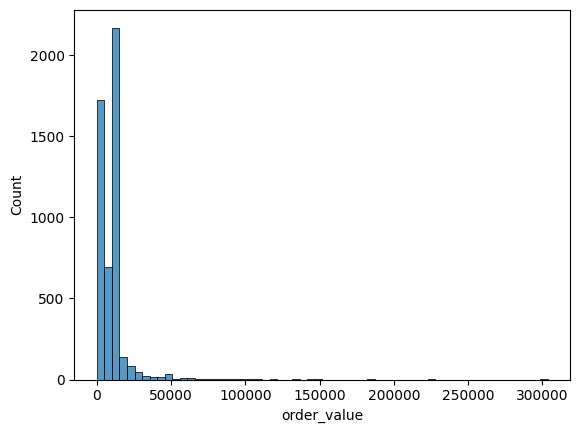

In [ ]:
sns.histplot(df['order_value'], bins=60)

In [ ]:
Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)
IQR = Q3 - Q1

IQR

10066.5

#### 🧭 Práctica Guiada 2 — Comparar antes y después en order_value

In [ ]:
df['order_value'].describe()

count      5000.000000
mean      10075.523800
std       12406.603152
min          12.000000
25%        3094.000000
50%       10341.000000
75%       13160.500000
max      303824.000000
Name: order_value, dtype: float64

<AxesSubplot:xlabel='order_value'>

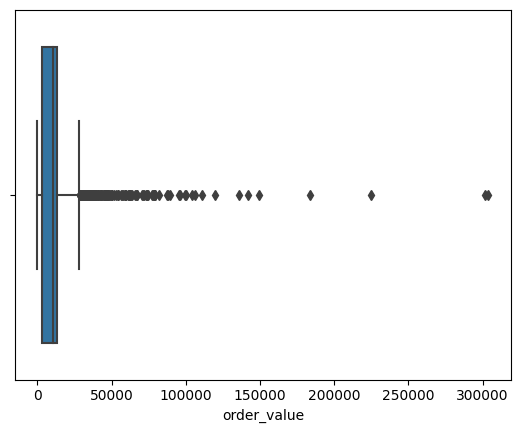

In [ ]:
sns.boxplot(x=df['order_value'])

<AxesSubplot:xlabel='order_value_capped'>

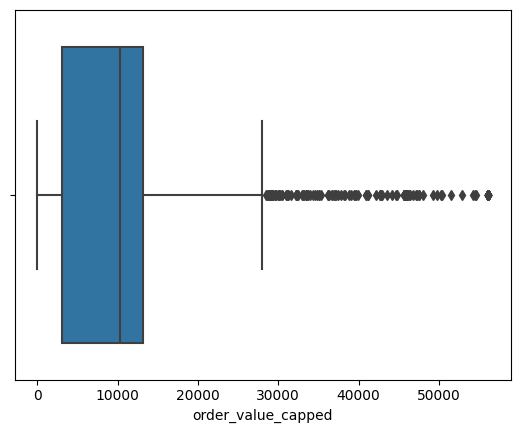

In [ ]:
p99 = df['order_value'].quantile(0.99)

df['order_value_capped'] = np.where( # Condicional
    df['order_value'] > p99,         # Condición a cumplir
    p99,                             # Valor si se cumple (pasa percentil 99, cambia valor)
    df['order_value']                # Valor si NO se cumple (no pasa percentil 99, mantiene valor)
)

sns.boxplot(x=df['order_value_capped'])

In [ ]:
df['order_value_capped'].describe()

count     5000.000000
mean      9694.762100
std       8677.328642
min         12.000000
25%       3094.000000
50%      10341.000000
75%      13160.500000
max      56150.670000
Name: order_value_capped, dtype: float64

In [ ]:
Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)
IQR = Q3 - Q1

IQR

10066.5

In [ ]:
Q1 = df["order_value_capped"].quantile(0.25)
Q3 = df["order_value_capped"].quantile(0.75)
IQR = Q3 - Q1

IQR

10066.5